## Samodzielna analiza skupień - produkty spożywcze

W tym notebooku wykorzystasz schemat analizy pokazany wcześniej na zbiorze Iris, ale zastosujesz go do innego, bardziej praktycznego zbioru danych.

Zbiór zawiera produkty spożywcze opisane przez zawartość różnych składników odżywczych, takich jak białko, tłuszcz, węglowodany, składniki mineralne i witaminy.

Celem analizy będzie pogrupowanie produktów spożywczych na podstawie ich profilu odżywczego.

W przeciwieństwie do zbioru Iris nie mamy tutaj zmiennej referencyjnej typu `species`.  
Nie znamy więc prawdziwego podziału produktów na grupy. Jakość segmentacji będziemy oceniać na podstawie miar wewnętrznych, liczności skupień, profili skupień oraz interpretowalności wyniku.

W pierwszej części notebooka przygotujemy dane do analizy:

- zaimportujemy dane,
- rozpoznamy strukturę zbioru,
- ocenimy braki danych,
- wykonamy podstawowe czyszczenie danych,
- sprawdzimy rozkłady i zależności między zmiennymi,
- przygotujemy dane do samodzielnej analizy skupień.

In [1]:
# Dodatkowe ułatwienia w ustawieniach wyświetlania i obsłudze ostrzeżeń

from IPython.display import display, HTML
import warnings
import os

# Wyłączenie przewijanej ramki wyników w Jupyterze
display(HTML("<style>.output_scroll { height: auto !important; }</style>"))

# Wyłączenie wybranych ostrzeżeń
warnings.simplefilter(action="ignore", category=UserWarning)

# Wyświetlenie aktualnego katalogu roboczego
print(os.getcwd())

C:\Users\wesol\Desktop\Studia\Semestr I\Eksploracja danych\Lab3


### Poniżej lista często wykorzystywanych bibliotek, ich rolę będziemy poznawali krok po kroku

In [2]:
# Struktury danych i podstawowe operacje
import pandas as pd
import numpy as np

# Wykresy
import matplotlib.pyplot as plt
import seaborn as sns

# Uzupełnianie braków danych
from sklearn.impute import SimpleImputer, KNNImputer

# Obsługa wartości odstających
from feature_engine.outliers import Winsorizer

# Skalowanie zmiennych
from sklearn.preprocessing import MinMaxScaler

# Wartość początkowa dla generatora liczb losowych
seed = 1

### Dodatkowe biblioteki potrzebne do analizy

In [3]:
# Jeśli biblioteka MiniSom nie jest zainstalowana, można ją doinstalować
#!pip install minisom

In [4]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from minisom import MiniSom
from sklearn.cluster import DBSCAN

## Co zawiera zbiór i po co robimy analizę?

Zbiór zawiera produkty spożywcze opisane przez zawartość różnych składników odżywczych, m.in. białka, tłuszczu, węglowodanów, składników mineralnych i witamin.

Celem analizy jest pogrupowanie produktów spożywczych w zależności od ich profilu odżywczego.

Wynik analizy powinien pozwolić odpowiedzieć na pytania:

- czy produkty tworzą naturalne grupy pod względem składu,
- czym różnią się otrzymane skupienia,
- które składniki najbardziej charakteryzują poszczególne grupy,
- czy skupienia dają się sensownie nazwać i zinterpretować.

### Import danych i pierwsze pytania do danych

1. Jaka jest struktura danych? 
2. Ile jest przypadków? Ile wierszy?
3. Co one oznaczają?
4. Jakie są typy kolumn w ramce danych?
5. Jaka jest liczba różnych wartości?

In [5]:
# Import danych z pliku xlsx do ramki danych food_df
# Plik powinien znajdować się w tym samym folderze co notebook.

data_path = "skladniki_simple.xlsx"

food_df = pd.read_excel(
    data_path,
    header=1,
    index_col=0
)

food_df.head()

,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,1001,717.0,0.85,81.11,0.06,24.0,NaN,0.02,684.0,0.005,0.0,NaN,0.0,0.034
"Cheese, cheddar",1009,404.0,22.87,33.31,3.09,710.0,455.0,0.14,330.0,0.029,0.0,0.6,0.0,0.428
"Cheese, cream",1017,350.0,6.15,34.44,5.52,97.0,107.0,0.11,308.0,0.023,0.0,NaN,0.0,0.230
"Cheese, feta",1019,264.0,14.21,21.28,4.09,493.0,337.0,0.65,125.0,0.154,0.0,0.4,0.0,0.844
Mozzarella,1026,300.0,22.17,22.35,2.19,505.0,354.0,0.44,179.0,0.030,0.0,0.4,0.0,0.283


In [6]:
# Jaka jest liczba przypadków? Jaka jest liczba zmiennych?
print(food_df.shape)

(69, 14)


In [7]:
# Pokazuje wszystkie kolumny zbioru podczas podglądu
pd.set_option("display.max_columns", None) 

# Wyświetlenie kilku pierwszych wierszy
food_df.head(10)

,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,1001,717.0,0.85,81.11,0.06,24.0,NaN,0.02,684.0,0.005,0.0,NaN,0.0,0.034
"Cheese, cheddar",1009,404.0,22.87,33.31,3.09,710.0,455.0,0.14,330.0,0.029,0.0,0.6,0.0,0.428
"Cheese, cream",1017,350.0,6.15,34.44,5.52,97.0,107.0,0.11,308.0,0.023,0.0,NaN,0.0,0.230
"Cheese, feta",1019,264.0,14.21,21.28,4.09,493.0,337.0,0.65,125.0,0.154,0.0,0.4,0.0,0.844
Mozzarella,1026,300.0,22.17,22.35,2.19,505.0,354.0,0.44,179.0,0.030,0.0,0.4,0.0,0.283
Parmesan,1032,420.0,28.42,27.84,13.91,853.0,627.0,0.49,262.0,0.026,0.0,0.5,0.0,0.358
Cream,1049,123.0,3.13,10.39,4.73,107.0,95.0,0.05,97.0,0.030,0.9,NaN,0.0,0.194
Milk,1078,64.0,3.28,3.66,4.65,119.0,93.0,0.05,33.0,0.038,1.5,NaN,NaN,NaN
Yogurt,1116,61.0,3.47,3.25,4.66,121.0,95.0,0.05,27.0,0.029,0.5,0.1,0.0,0.142
Egg,1128,196.0,13.61,14.84,0.83,62.0,215.0,1.89,219.0,0.044,0.0,2.2,0.0,0.495


In [8]:
# Podstawowe sprawdzenie typów danych
food_df.dtypes

ID                    int64
Energia (kcal)      float64
Białko (g)          float64
Tłuszcz (g)         float64
Węglowodany (g)     float64
Wapń (mg)           float64
Fosfor (mg)         float64
Żelazo (mg)         float64
Witamina A (ug)     float64
Witamina B1 (mg)    float64
Witamina C (mg)     float64
Witamina D (ug)     float64
Błonnik (g)         float64
Witamina B2 (mg)    float64
dtype: object

In [9]:
# Sprawdzenie liczby unikalnych wartości
food_df.nunique()

ID                  69
Energia (kcal)      62
Białko (g)          67
Tłuszcz (g)         60
Węglowodany (g)     56
Wapń (mg)           58
Fosfor (mg)         57
Żelazo (mg)         57
Witamina A (ug)     37
Witamina B1 (mg)    54
Witamina C (mg)     32
Witamina D (ug)     16
Błonnik (g)         23
Witamina B2 (mg)    50
dtype: int64

## Pierwsza decyzja: rola zmiennych w analizie

Do analizy skupień wykorzystamy zmienne liczbowe opisujące skład produktów.

Kolumna identyfikująca produkt nie powinna być traktowana jako zmienna analityczna.  
Jeżeli identyfikator produktu został wczytany jako indeks ramki danych, nie trzeba go dodatkowo usuwać z listy zmiennych.

In [10]:
# Określ rolę zmiennych w analizie 
id_variable = ['ID']
predictors = [var for var in food_df.columns if var not in id_variable]

In [11]:
print(predictors)

['Energia (kcal)', 'Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


## Brak zmiennej referencyjnej

W tym zbiorze nie mamy zmiennej, która mówiłaby, do jakiej „prawdziwej” grupy należy dany produkt.

Jest to typowa sytuacja w analizie skupień.  
Nie możemy więc ocenić modelu przez porównanie z rzeczywistymi etykietami, tak jak robiliśmy to w zbiorze Iris za pomocą zmiennej `species`.

W tej analizie jakość skupień będziemy oceniać na podstawie:

- miar wewnętrznych, takich jak wskaźnik sylwetki,
- liczności skupień,
- profili skupień,
- interpretowalności otrzymanych grup.

## Ocena jakości zbioru danych

Przed modelowaniem sprawdzimy jakość danych.

Na tym etapie ocenimy:

- braki danych w zmiennych,
- braki danych w obrębie obserwacji,
- podstawowe rozkłady zmiennych ilościowych,
- potencjalne wartości odstające,
- zmienne, które mogą wymagać imputacji lub usunięcia.

W tym zbiorze szczególnie ważna będzie analiza braków danych, ponieważ niektóre produkty mogą mieć niepełny opis składu.

In [12]:
# Raport braków danych dla zmiennych używanych w analizie

missing_report = pd.DataFrame({
    "Liczba braków": food_df[predictors].isnull().sum(),
    "Procent braków": (food_df[predictors].isnull().mean() * 100).round(2)
})

missing_report.sort_values("Procent braków", ascending=False)

,Liczba braków,Procent braków
Witamina D (ug),22,31.88
Witamina B2 (mg),15,21.74
Błonnik (g),14,20.29
Fosfor (mg),9,13.04
Witamina A (ug),6,8.70
Witamina C (mg),5,7.25
Witamina B1 (mg),5,7.25
Wapń (mg),2,2.90
Energia (kcal),0,0.00
Węglowodany (g),0,0.00


W przeciwieństwie do zbioru Iris, tutaj występują braki danych.

Zanim zdecydujemy, jak je uzupełnić, warto sprawdzić nie tylko braki w poszczególnych zmiennych, ale także to, czy niektóre produkty mają szczególnie dużo brakujących informacji.

In [13]:
# Analiza braków danych w obrębie obserwacji

null_row_report = pd.DataFrame({
    "Odsetek braków": food_df[predictors].isnull().mean(axis=1)
})

null_row_report = null_row_report.sort_values(
    "Odsetek braków",
    ascending=False
)

null_row_report.head(10)

,Odsetek braków
Cocoa butter,0.538462
Chocolate ice cream,0.538462
"ESTLE, CRUNCH Bar and Dessert Topping",0.538462
Oil,0.461538
"HERSHEY, KIT KAT BIG KAT Bar",0.384615
Veal,0.384615
Olive,0.307692
Chocolate,0.307692
Tuna,0.230769
Lamb,0.230769


## Pierwsza ingerencja w dane

Część produktów może mieć bardzo dużo brakujących wartości.  
Takie obserwacje mogą być trudne do wiarygodnego uzupełnienia i mogą zaburzać wynik analizy skupień.

W tym przykładzie usuniemy z analizy produkty, dla których brakuje więcej niż 40% wartości zmiennych używanych w analizie.

Jest to decyzja analityczna - w innych projektach próg ten może być inny i powinien zależeć od kontekstu danych.

### Pierwsza ingerencja w dane

In [14]:
# Zachowujemy kopię danych przed usunięciem obserwacji
food_df_before_row_filtering = food_df.copy()

# Usuwamy z analizy obserwacje, dla których odsetek braków danych przekracza 40%
row_missing_share = food_df[predictors].isnull().mean(axis=1)
food_df = food_df.loc[row_missing_share <= 0.4].copy()

print(food_df.shape)

(65, 14)


In [15]:
# Ponowny raport braków danych po usunięciu obserwacji z dużą liczbą braków

missing_report = pd.DataFrame({
    "Liczba braków": food_df[predictors].isnull().sum(),
    "Procent braków": (food_df[predictors].isnull().mean() * 100).round(2)
})

missing_report.sort_values("Procent braków", ascending=False)

,Liczba braków,Procent braków
Witamina D (ug),18,27.69
Błonnik (g),11,16.92
Witamina B2 (mg),11,16.92
Fosfor (mg),5,7.69
Witamina C (mg),3,4.62
Witamina A (ug),2,3.08
Witamina B1 (mg),1,1.54
Wapń (mg),0,0.00
Białko (g),0,0.00
Energia (kcal),0,0.00


## Wybór techniki uzupełniania braków danych

Po usunięciu obserwacji z bardzo dużą liczbą braków nadal mogą pozostać pojedyncze braki w zmiennych.

Sposób uzupełniania braków zależy między innymi od ich liczby:

- dla zmiennych z niewielkim odsetkiem braków można zastosować prostą imputację medianą,
- dla zmiennych z większym odsetkiem braków można rozważyć bardziej zaawansowaną metodę, np. imputację KNN.

W tym przykładzie przyjmiemy próg 5% braków danych.

In [16]:
# Podział zmiennych z brakami danych według odsetka braków

missing_over_5 = [
    var for var in predictors
    if food_df[var].isnull().mean() >= 0.05
]

missing_below_5 = [
    var for var in predictors
    if 0 < food_df[var].isnull().mean() < 0.05
]

print("Zmienne z odsetkiem braków >= 5%:")
print(missing_over_5)

print("\nZmienne z odsetkiem braków < 5%:")
print(missing_below_5)

Zmienne z odsetkiem braków >= 5%:
['Fosfor (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']

Zmienne z odsetkiem braków < 5%:
['Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)']


## Badanie rozkładów zmiennych

Po analizie braków danych sprawdzimy rozkłady zmiennych ilościowych.

Na tym etapie interesuje nas:

- liczba unikalnych wartości,
- podstawowe statystyki opisowe,
- kształt rozkładów,
- potencjalne wartości odstające,
- zmienne o bardzo nietypowym zakresie wartości.

W tym zbiorze do analizy skupień wykorzystujemy zmienne ilościowe opisujące skład produktów.  
Nie mamy tutaj zmiennych jakościowych, dlatego nie wykonujemy osobnej analizy tabel liczności dla kategorii.

In [17]:
# Liczba unikalnych wartości w zmiennych używanych w analizie

food_df[predictors].nunique().sort_values()

Witamina D (ug)     16
Błonnik (g)         23
Witamina C (mg)     32
Witamina A (ug)     37
Witamina B2 (mg)    50
Węglowodany (g)     54
Żelazo (mg)         54
Witamina B1 (mg)    54
Wapń (mg)           56
Fosfor (mg)         57
Tłuszcz (g)         58
Energia (kcal)      60
Białko (g)          65
dtype: int64

In [18]:
# Podsumowanie podstawowych statystyk opisowych
food_df[predictors].describe().T

,count,mean,std,min,25%,50%,75%,max
Energia (kcal),65.0,206.429671,194.581850,16.000,63.000000,150.137255,268.800000,884.000000
Białko (g),65.0,10.122807,9.794732,0.000,1.180000,5.400000,20.080000,29.386667
Tłuszcz (g),65.0,12.492926,19.447059,0.070,0.430000,6.102059,18.000000,100.000000
Węglowodany (g),65.0,13.785516,21.886636,0.000,0.300092,4.110000,14.450000,87.730000
Wapń (mg),65.0,83.140843,155.580390,1.000,14.857143,33.000000,76.000000,853.000000
Fosfor (mg),60.0,147.323783,121.678867,4.000,52.750000,113.000000,201.500000,627.000000
Żelazo (mg),65.0,1.310656,1.702505,0.020,0.300000,0.710000,1.700000,8.212000
Witamina A (ug),63.0,91.857143,182.008052,0.000,0.000000,20.000000,88.000000,835.000000
Witamina B1 (mg),64.0,0.091697,0.105625,0.005,0.029000,0.050544,0.116500,0.575000
Witamina C (mg),62.0,9.391935,18.979707,0.000,0.000000,0.900000,7.350000,92.700000


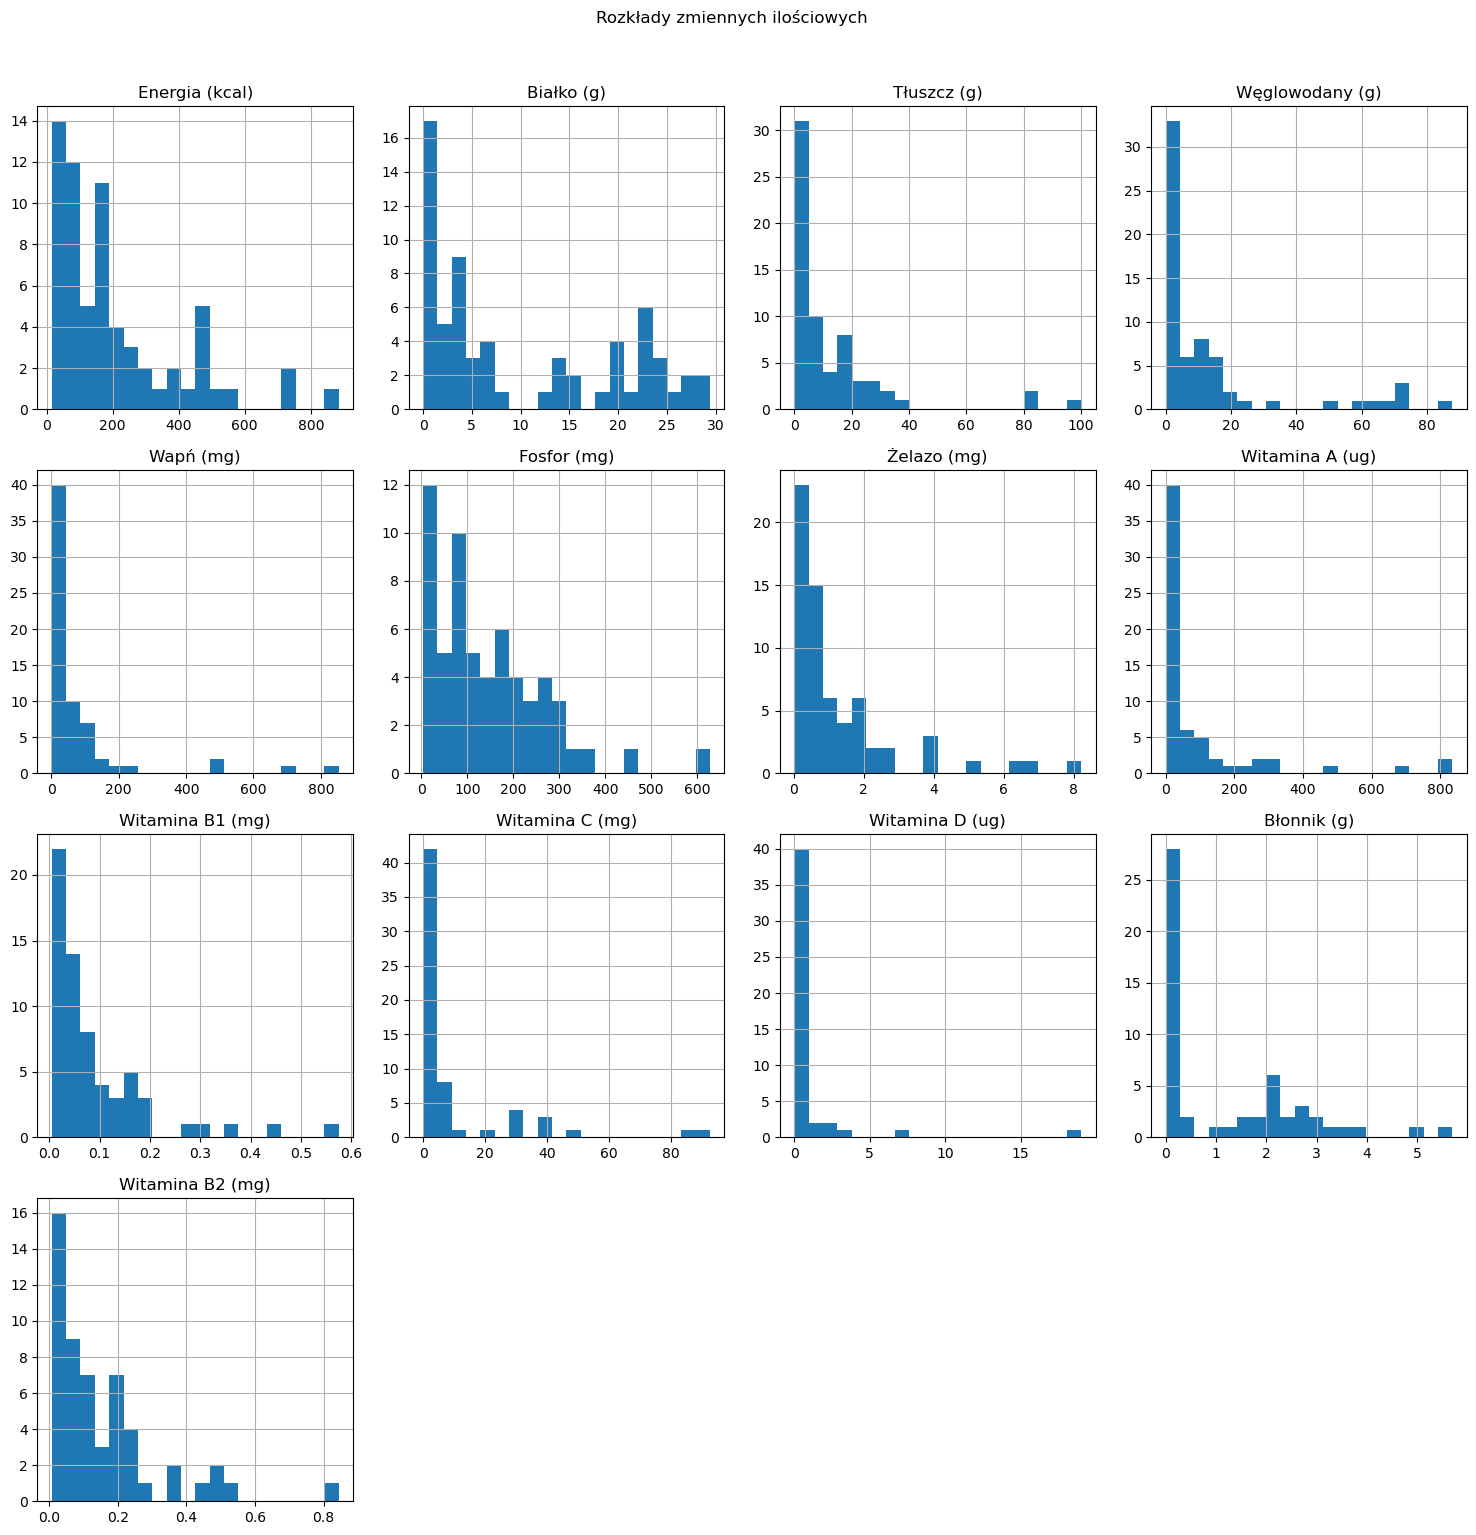

In [19]:
# Histogramy dla zmiennych ilościowych

food_df[predictors].hist(
    bins=20,
    figsize=(15, 15)
)

plt.suptitle("Rozkłady zmiennych ilościowych", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
def plot_box_strip(df, variables, hue=None):
    """
    Tworzy wykresy pudełkowe z nałożonymi punktami obserwacji dla podanych zmiennych.

    Parametry:
    - df: DataFrame zawierający dane,
    - variables: lista nazw kolumn ze zmiennymi ilościowymi,
    - hue: opcjonalna zmienna grupująca.
    """

    for var in variables:
        plt.figure(figsize=(8, 6))

        sns.boxplot(
            data=df,
            y=var,
            x=hue,
            fliersize=0,
            color="green"
        )

        sns.stripplot(
            data=df,
            y=var,
            x=hue,
            jitter=0.1,
            alpha=0.3,
            color="black"
        )

        plt.title(f"Wykres pudełkowy z obserwacjami: {var}")
        plt.xlabel(hue if hue else "")
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

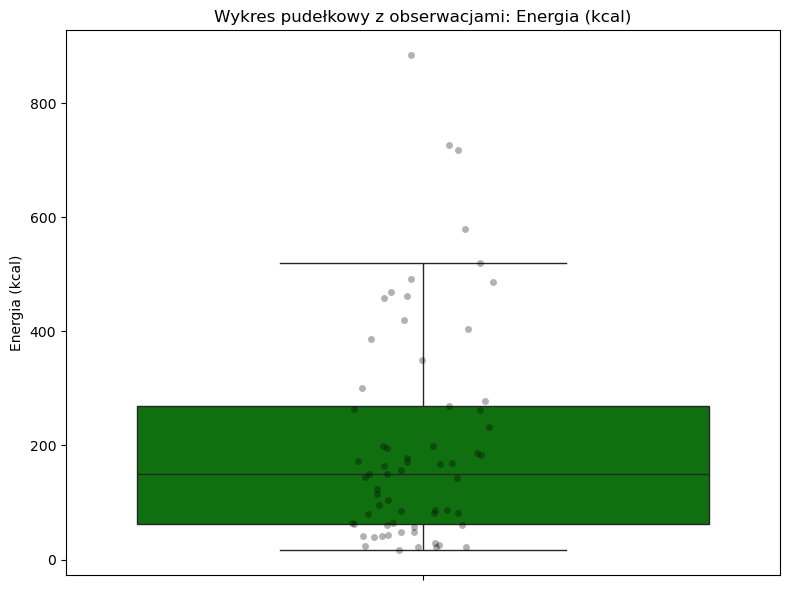

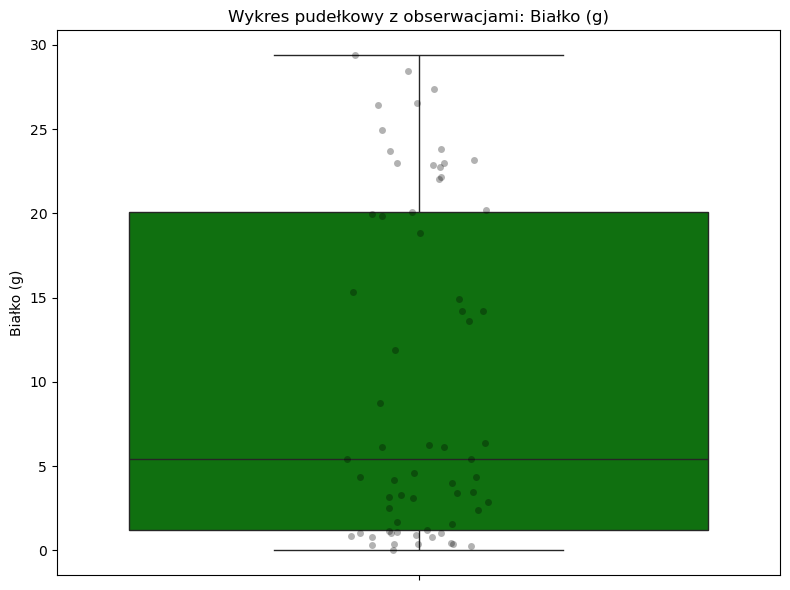

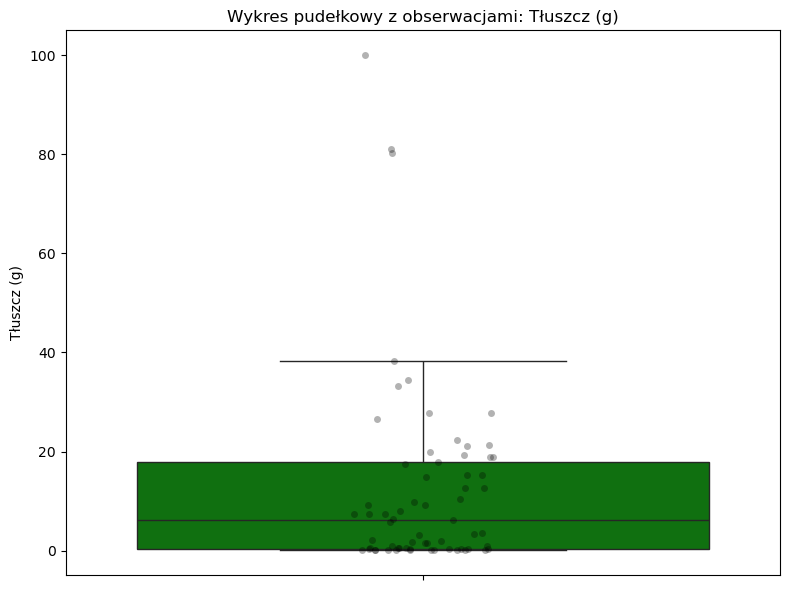

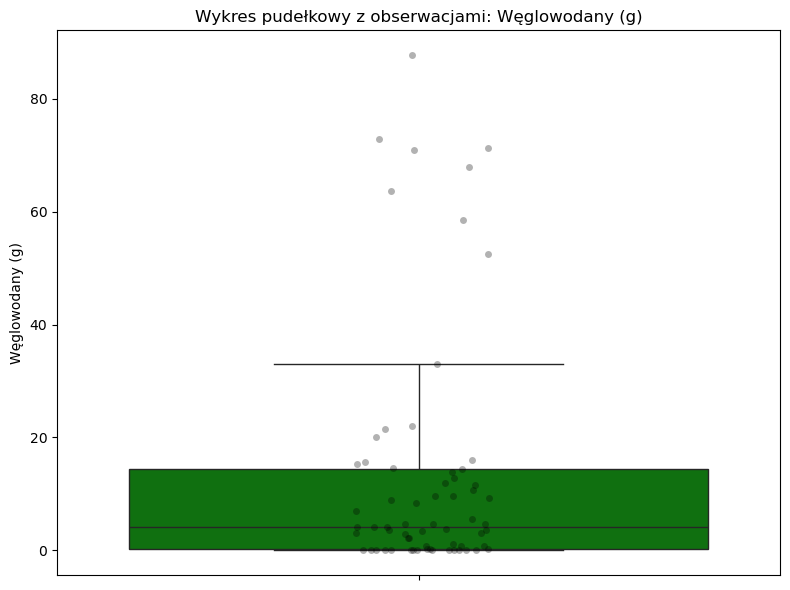

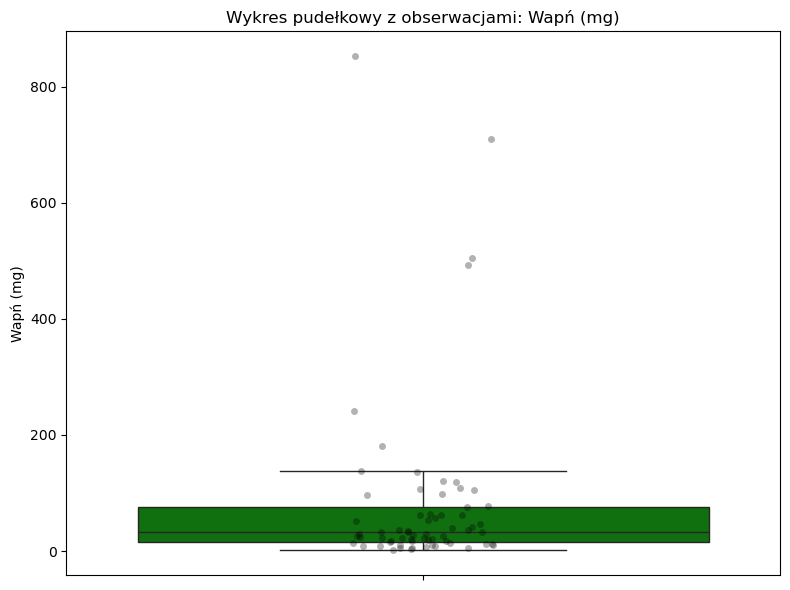

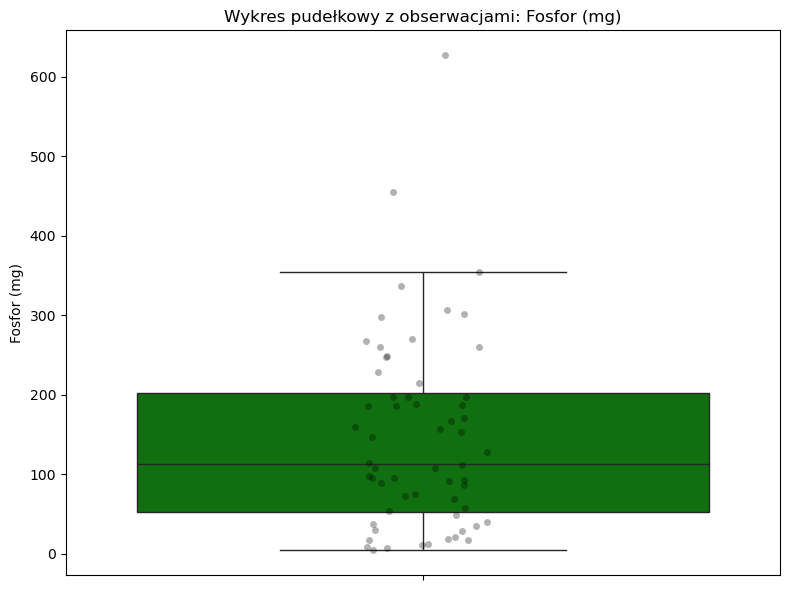

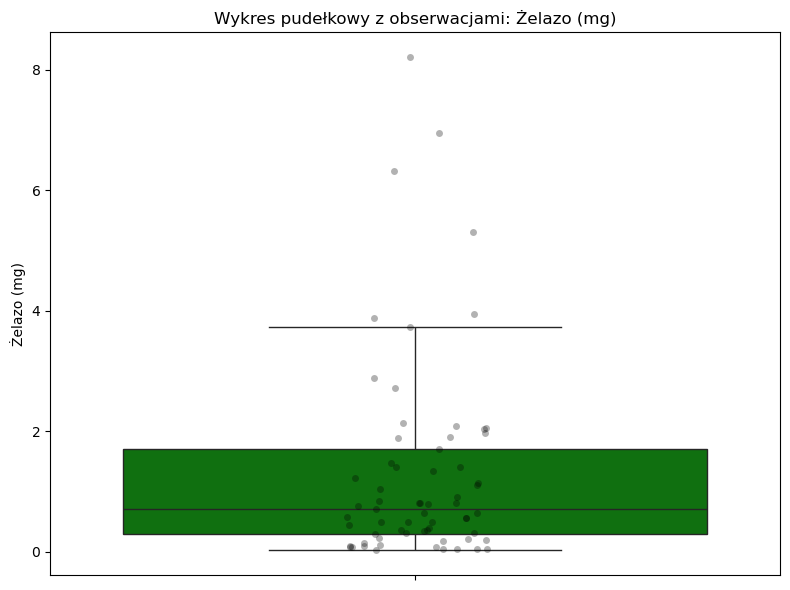

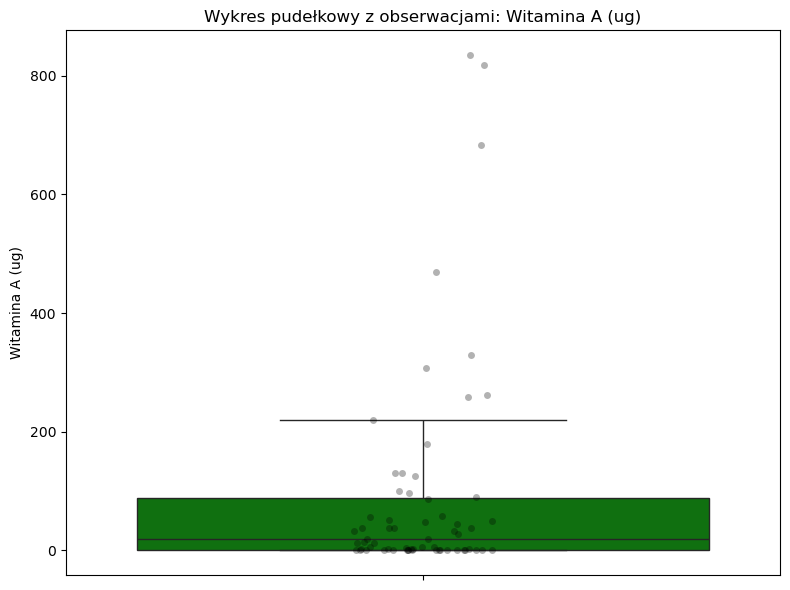

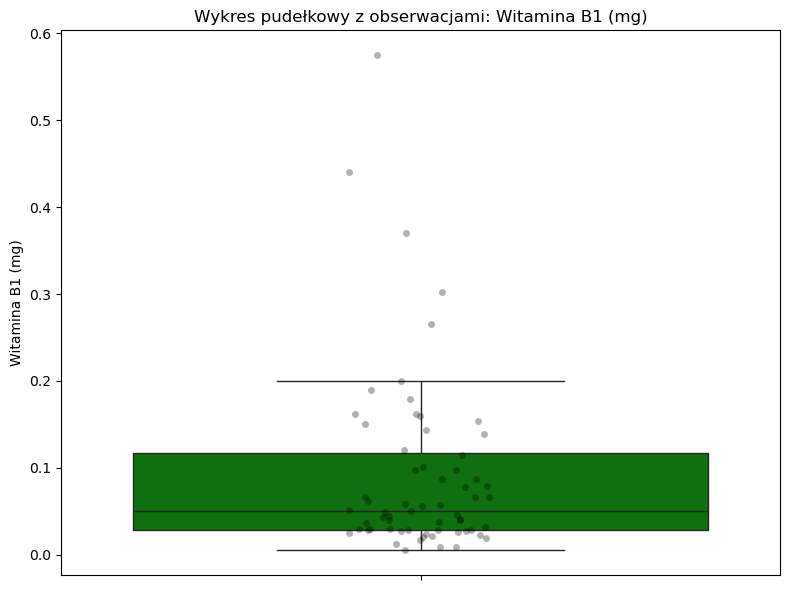

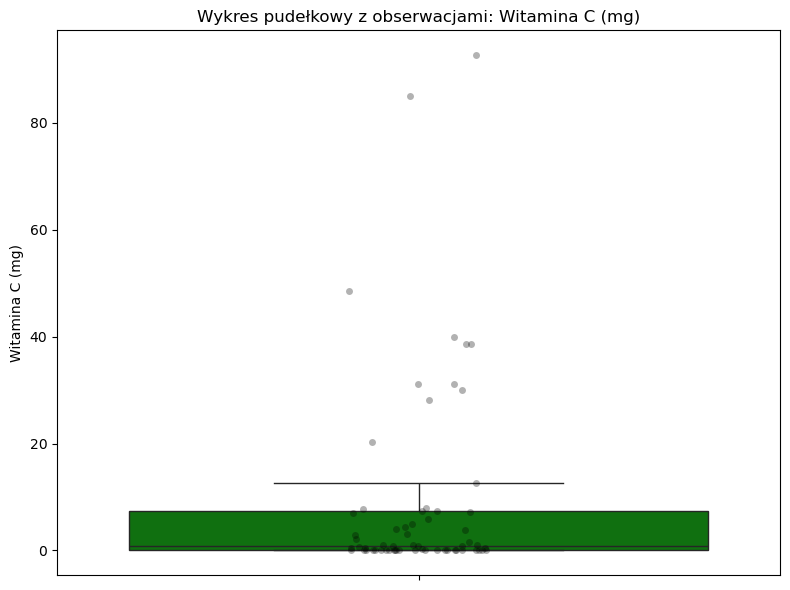

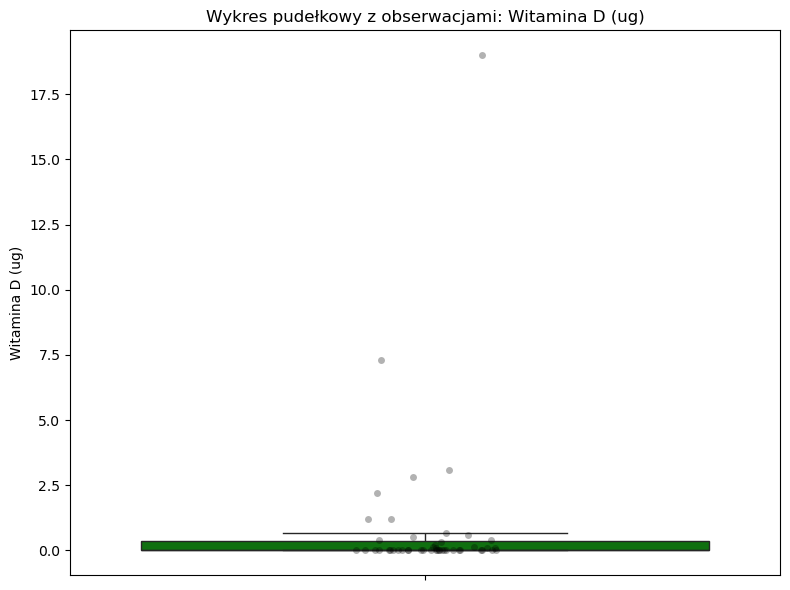

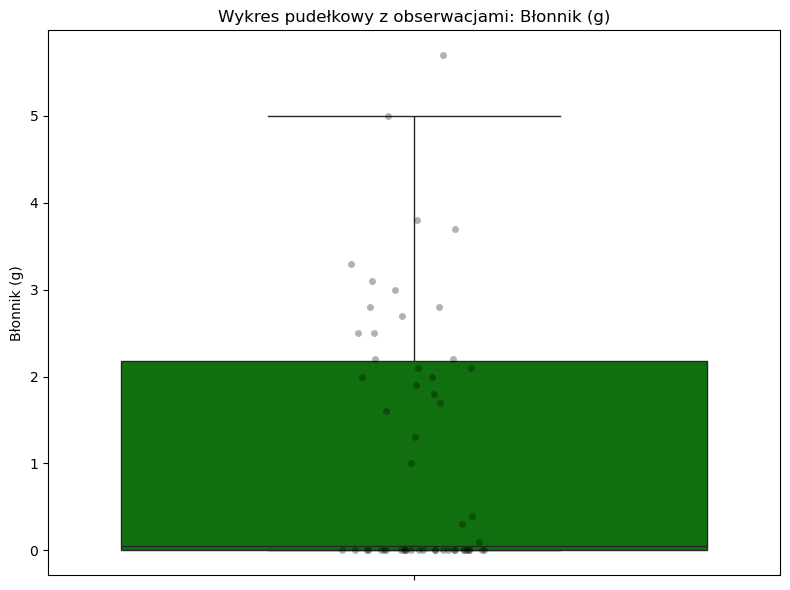

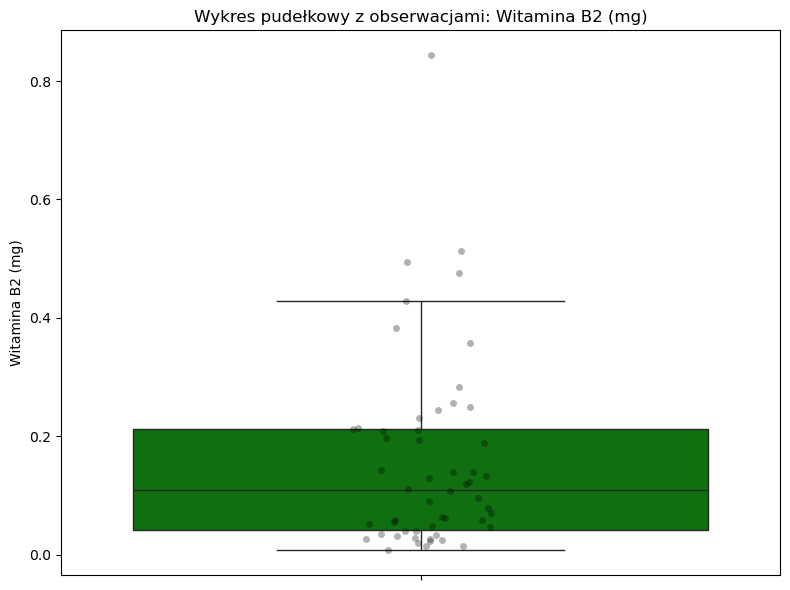

In [21]:
plot_box_strip(food_df, predictors)

Wykresy histogramów i wykresy pudełkowe pomagają ocenić, czy zmienne mają rozkłady symetryczne, skośne lub zawierają wartości nietypowe.

W analizie produktów spożywczych wartości odstające nie muszą oznaczać błędów.  
Produkt o bardzo wysokiej zawartości tłuszczu, błonnika albo określonego mikroelementu może być po prostu specyficznym produktem, a nie błędną obserwacją.

Dlatego wartości odstające należy najpierw zidentyfikować, a dopiero później zdecydować, czy wymagają przycięcia, usunięcia albo pozostawienia w analizie.

## Czyszczenie danych: uzupełnianie braków

Po rozpoznaniu danych przechodzimy do ich przygotowania do analizy skupień.

W tym zbiorze występują braki danych, dlatego musimy zdecydować, jak je uzupełnić.

Przyjmujemy następującą strategię:

- zmienne z niewielkim odsetkiem braków uzupełnimy medianą,
- zmienne z większym odsetkiem braków uzupełnimy metodą KNN.

Warto pamiętać, że wybór metody imputacji jest decyzją analityczną.  
W innych projektach sposób uzupełniania braków powinien zależeć od charakteru danych, skali zmiennych oraz celu analizy.

In [22]:
# Uzupełnianie braków danych

# Dla zmiennych z niewielkim odsetkiem braków stosujemy medianę
if len(missing_below_5) > 0:
    simple_imputer = SimpleImputer(strategy="median")
    food_df.loc[:, missing_below_5] = simple_imputer.fit_transform(
        food_df[missing_below_5]
    )

# Dla pozostałych braków stosujemy imputację KNN
# Uwaga: KNN opiera się na odległościach, więc w bardziej rygorystycznej analizie
# warto rozważyć wcześniejsze przeskalowanie zmiennych.

knn_imputer = KNNImputer(
    n_neighbors=3,
    weights="distance"
)

food_df.loc[:, predictors] = knn_imputer.fit_transform(food_df[predictors])

# Sprawdzenie, czy braki zostały uzupełnione

null_report_after_imputation = food_df[predictors].isnull().mean().sort_values(
    ascending=False
)

null_report_after_imputation

Energia (kcal)      0.0
Białko (g)          0.0
Tłuszcz (g)         0.0
Węglowodany (g)     0.0
Wapń (mg)           0.0
Fosfor (mg)         0.0
Żelazo (mg)         0.0
Witamina A (ug)     0.0
Witamina B1 (mg)    0.0
Witamina C (mg)     0.0
Witamina D (ug)     0.0
Błonnik (g)         0.0
Witamina B2 (mg)    0.0
dtype: float64

> **Uwaga metodyczna**
>
> Imputacja KNN opiera się na podobieństwie obserwacji, które jest wyznaczane na podstawie odległości między nimi.
>
> Oznacza to, że zmienne o większych wartościach lub szerszym zakresie mogą mieć silniejszy wpływ na wynik uzupełniania braków danych.
>
> W tym przykładzie pozostawiamy procedurę w uproszczonej formie, ale w bardziej rygorystycznej analizie warto rozważyć przeskalowanie zmiennych przed zastosowaniem imputacji KNN.

## Czyszczenie danych: wartości odstające

Kolejnym krokiem jest ocena wartości odstających.

Wartości odstające nie zawsze są błędami. W przypadku produktów spożywczych mogą oznaczać produkty rzeczywiście nietypowe, np. bardzo tłuste, bardzo bogate w białko albo zawierające wyjątkowo dużo wybranego składnika.

W tym przykładzie zastosujemy winsoryzację, czyli przycięcie wartości skrajnych do granic wyznaczonych metodą IQR.  
Traktujemy to jako jedną z możliwych metod ograniczania wpływu wartości ekstremalnych na analizę skupień.

In [23]:
# Zachowujemy kopię danych przed winsoryzacją

food_df_before_winsorization = food_df.copy()

# capping_method='iqr' - metoda oparta na rozstępie kwartylowym
# fold=1.5 - parametr sterujący szerokością granic przycinania
# tail='both' - przycinanie wartości odstających z obu stron rozkładu

winsorizer = Winsorizer(
    capping_method="iqr",
    fold=1.5,
    tail="both"
)

food_df.loc[:, predictors] = winsorizer.fit_transform(food_df[predictors])

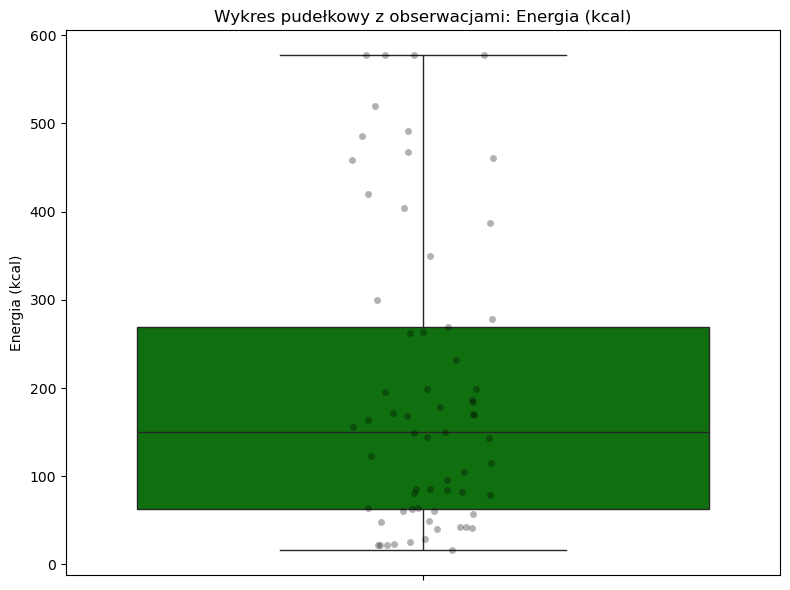

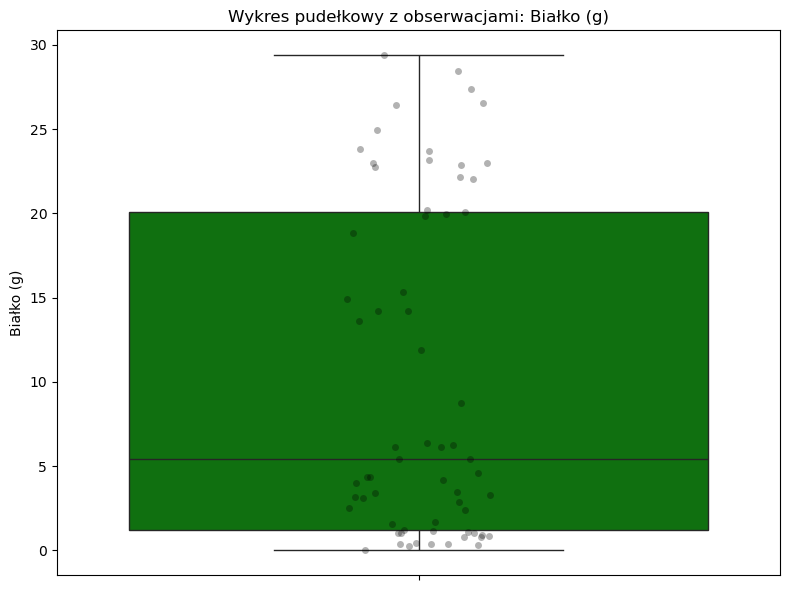

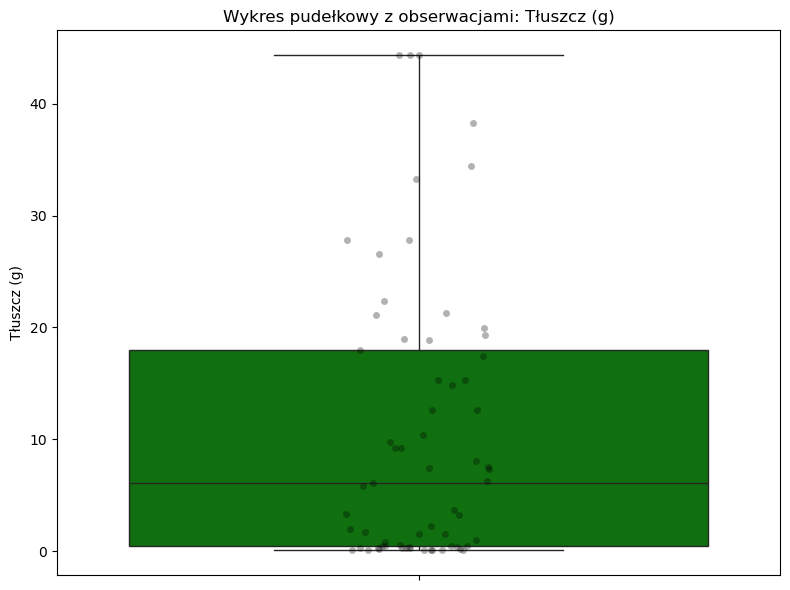

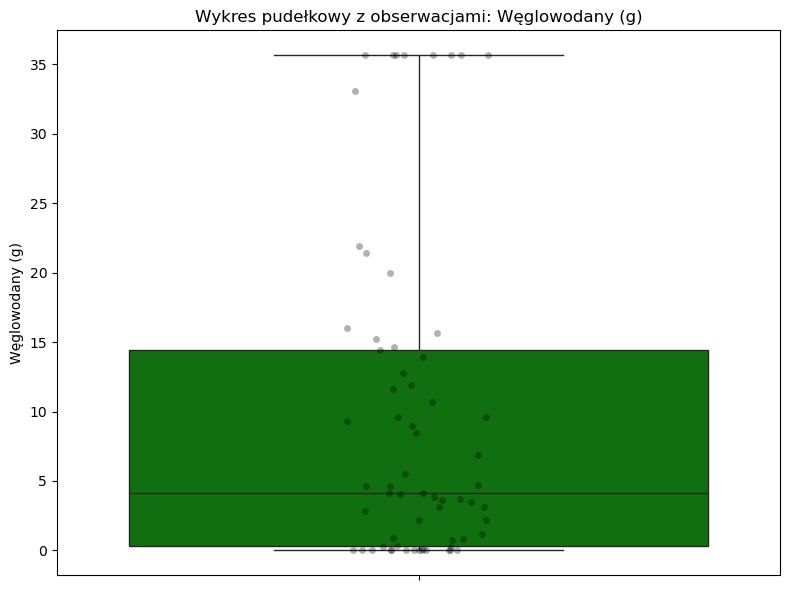

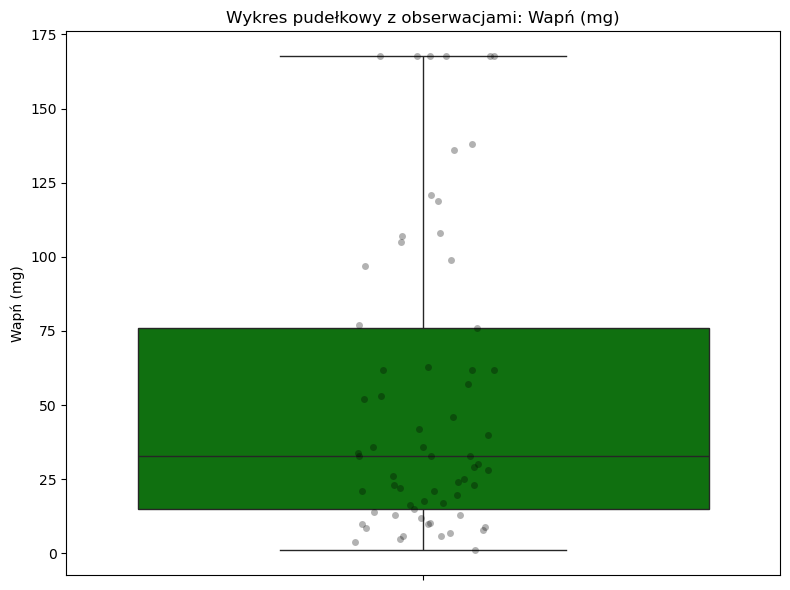

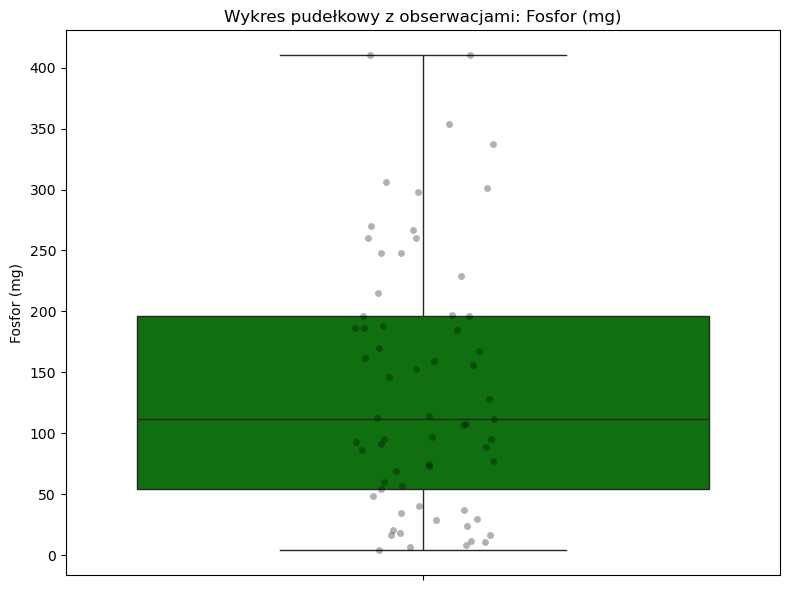

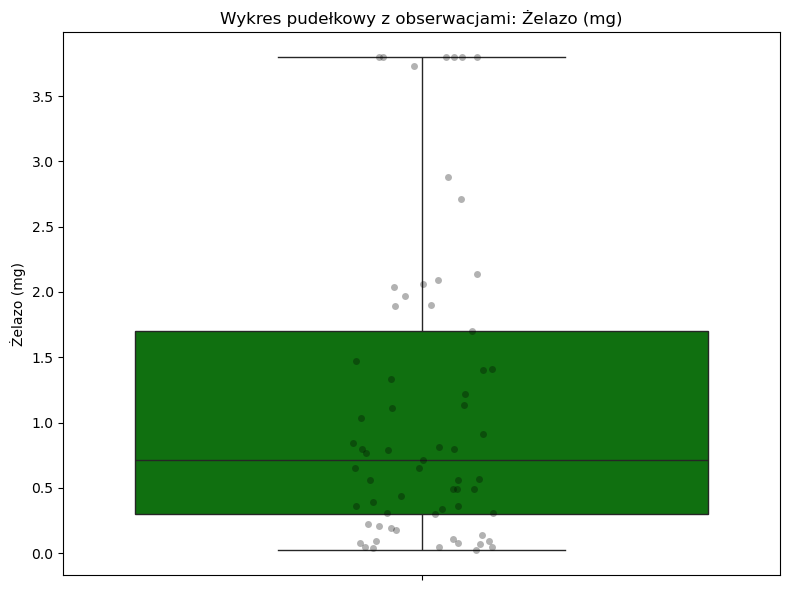

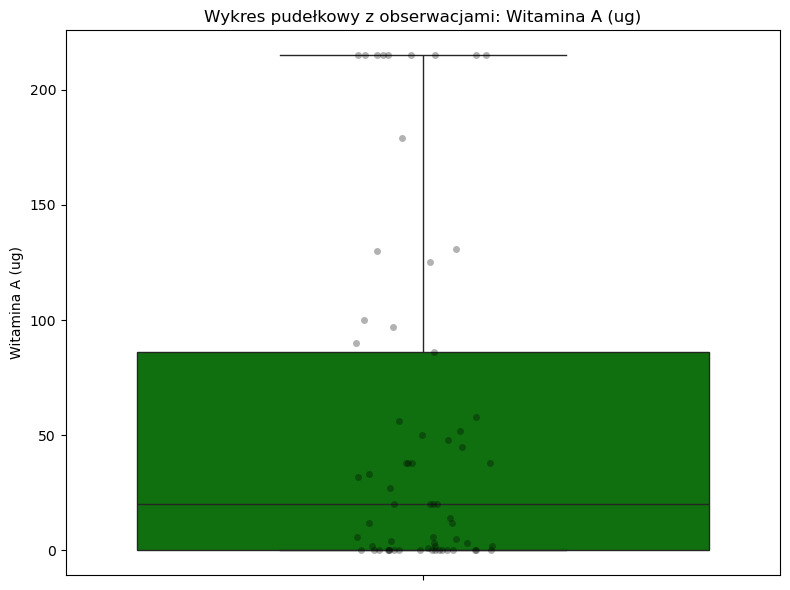

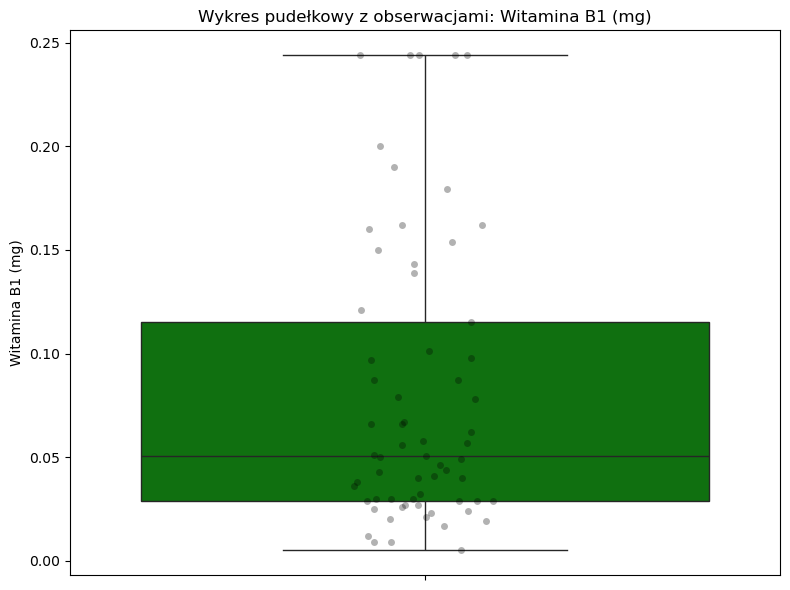

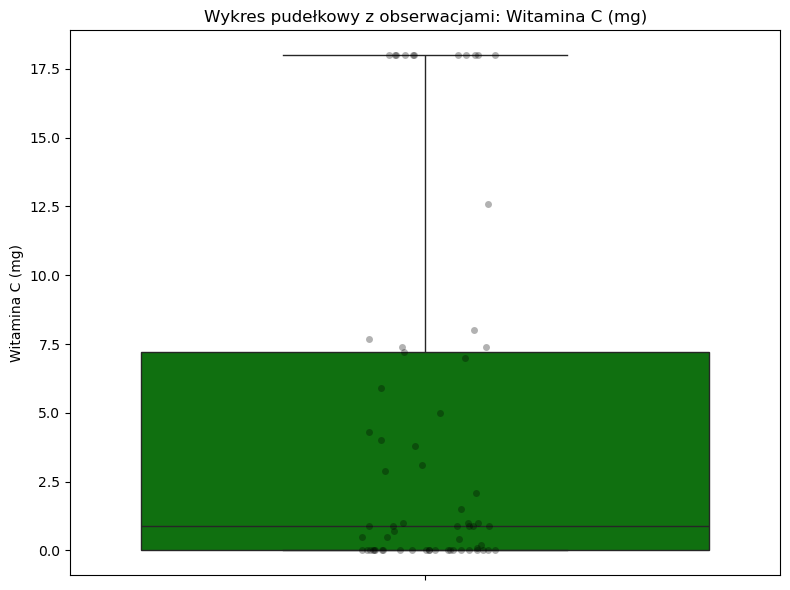

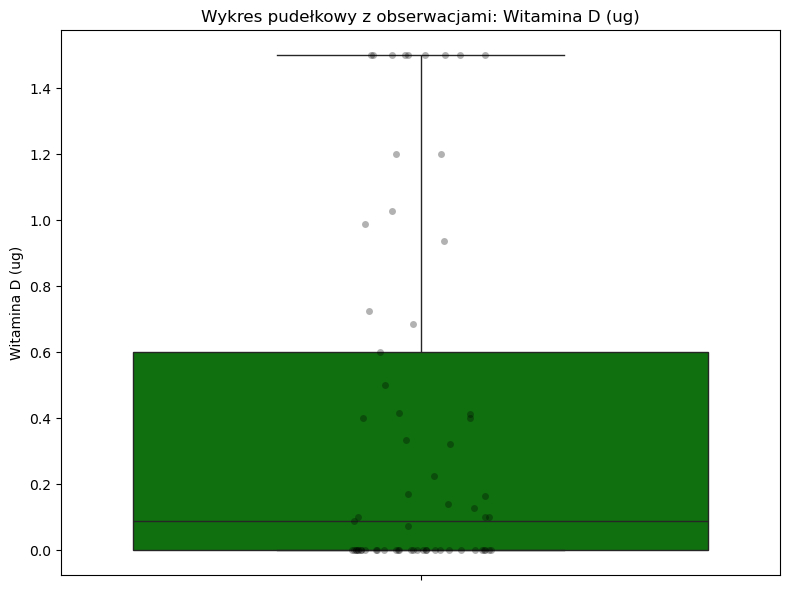

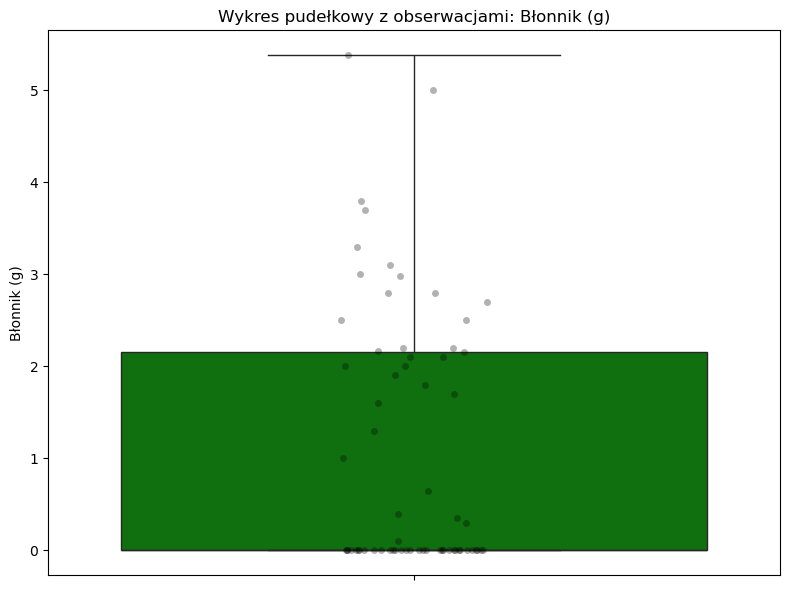

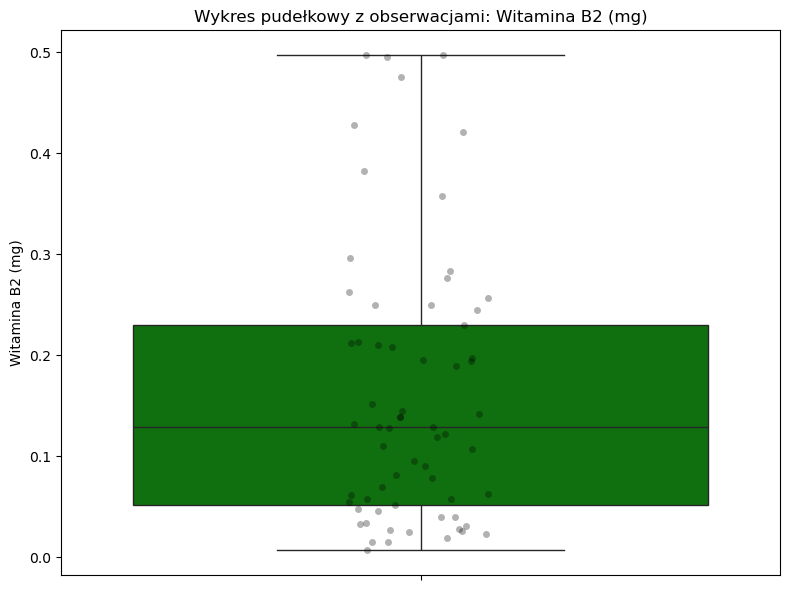

In [24]:
# Sprawdzenie efektu winsoryzacji
plot_box_strip(food_df, predictors)

## Powiązania pomiędzy zmiennymi

Przed skalowaniem i modelowaniem warto sprawdzić zależności pomiędzy zmiennymi.

Silnie skorelowane zmienne mogą wnosić podobną informację do modelu.  
Nie oznacza to automatycznie, że którąś z nich trzeba usunąć, ale może być podstawą do rozważenia uproszczenia zestawu zmiennych.

W tym celu obliczymy korelacje Spearmana i przedstawimy je na mapie ciepła.

In [25]:
# Obliczanie macierzy korelacji rang Spearmana

spearman_corr_matrix = food_df[predictors].corr(method="spearman")

spearman_corr_matrix

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Energia (kcal),1.000000,0.368840,0.915020,0.000373,0.173933,0.558738,0.188796,0.086258,-0.071329,-0.735078,0.307367,-0.347880,0.410785
Białko (g),0.368840,1.000000,0.383197,-0.499357,0.197153,0.866297,0.518662,0.020996,0.282332,-0.440510,0.691088,-0.548094,0.727771
Tłuszcz (g),0.915020,0.383197,1.000000,-0.136946,0.309192,0.583465,0.157732,0.237116,-0.073172,-0.745210,0.377403,-0.411671,0.505300
Węglowodany (g),0.000373,-0.499357,-0.136946,1.000000,0.262279,-0.522945,-0.122021,-0.035821,-0.119997,0.309969,-0.684078,0.647069,-0.363161
Wapń (mg),0.173933,0.197153,0.309192,0.262279,1.000000,0.233798,0.057907,0.623478,0.000252,0.009130,0.108199,0.028285,0.264030
Fosfor (mg),0.558738,0.866297,0.583465,-0.522945,0.233798,1.000000,0.393939,0.135884,0.188310,-0.543722,0.709349,-0.649446,0.724470
Żelazo (mg),0.188796,0.518662,0.157732,-0.122021,0.057907,0.393939,1.000000,-0.149633,0.554648,-0.069697,0.123532,0.022961,0.460012
Witamina A (ug),0.086258,0.020996,0.237116,-0.035821,0.623478,0.135884,-0.149633,1.000000,-0.180226,0.053398,0.327542,-0.095391,0.147446
Witamina B1 (mg),-0.071329,0.282332,-0.073172,-0.119997,0.000252,0.188310,0.554648,-0.180226,1.000000,0.154910,-0.076594,0.062860,0.358586
Witamina C (mg),-0.735078,-0.440510,-0.745210,0.309969,0.009130,-0.543722,-0.069697,0.053398,0.154910,1.000000,-0.473471,0.569228,-0.464166


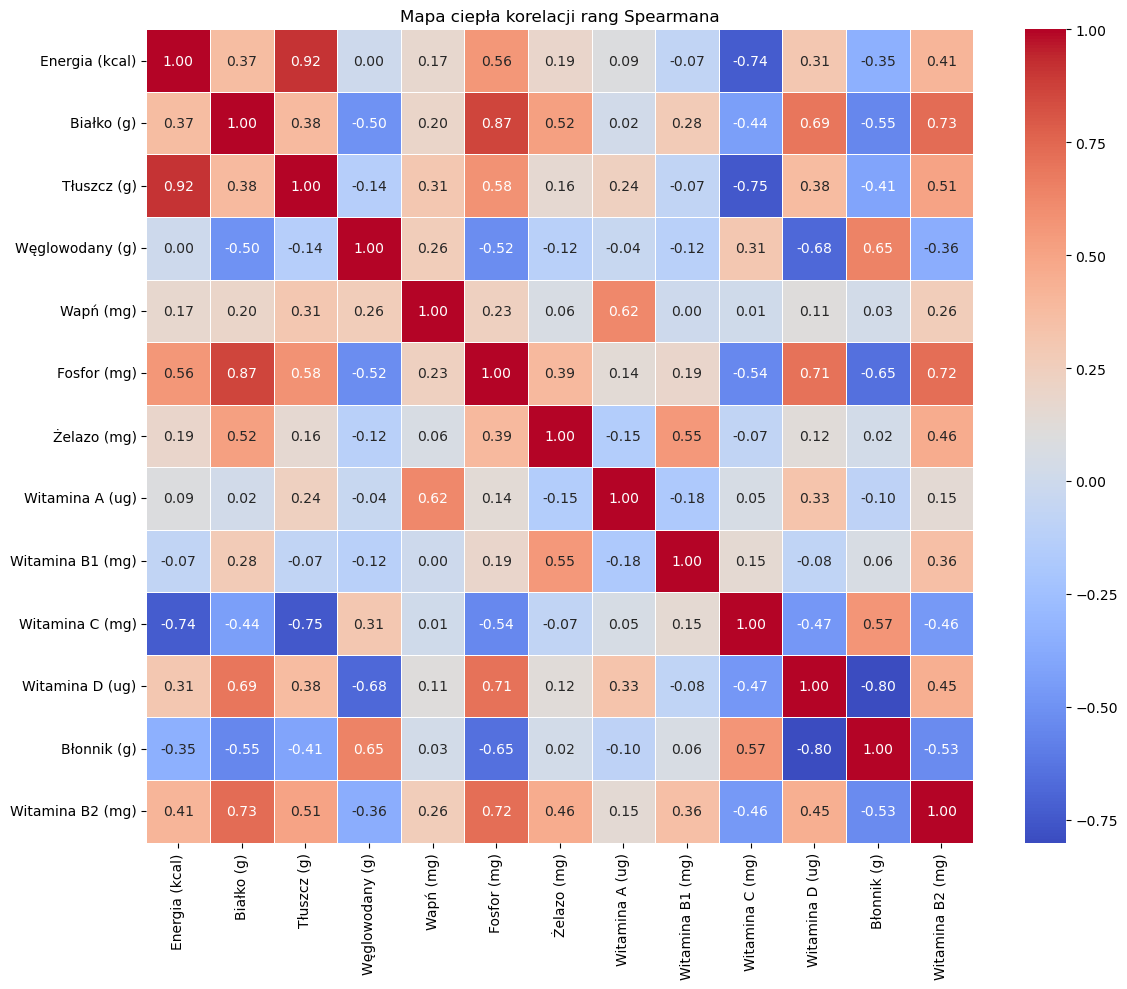

In [26]:
# Mapa ciepła korelacji

plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa ciepła korelacji rang Spearmana")
plt.tight_layout()
plt.show()

Zmienne `Tłuszcz (g)` oraz `Energia (kcal)` są silnie powiązane.

Możemy rozważyć usunięcie jednej z nich, aby ograniczyć powielanie podobnej informacji w analizie.  
W tym przykładzie usuniemy zmienną `Energia (kcal)`, ponieważ jest ona w dużej mierze pochodną składu odżywczego produktu.

In [27]:
# Usunięcie zmiennej Energia (kcal) z listy predyktorów

predictors = [var for var in predictors if var != "Energia (kcal)"]

print(predictors)

['Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


In [28]:
def scatter_plot(df, variables, hue=None):
    """
    Tworzy wykres rozrzutu dla dwóch podanych zmiennych.

    Parametry:
    - df: DataFrame z danymi,
    - variables: lista dokładnie 2 nazw kolumn [x, y],
    - hue: opcjonalna zmienna jakościowa do kolorowania punktów.
    """

    if len(variables) != 2:
        raise ValueError("Lista 'variables' musi zawierać dokładnie 2 zmienne.")

    x, y = variables

    plt.figure(figsize=(8, 6))

    if hue:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, palette="Set1", alpha=0.7)
        plt.legend(title=hue)
    else:
        sns.scatterplot(data=df, x=x, y=y, alpha=0.7)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Wykres rozrzutu: {x} vs {y}")
    plt.tight_layout()
    plt.show()

In [29]:
print(predictors)

['Białko (g)', 'Tłuszcz (g)', 'Węglowodany (g)', 'Wapń (mg)', 'Fosfor (mg)', 'Żelazo (mg)', 'Witamina A (ug)', 'Witamina B1 (mg)', 'Witamina C (mg)', 'Witamina D (ug)', 'Błonnik (g)', 'Witamina B2 (mg)']


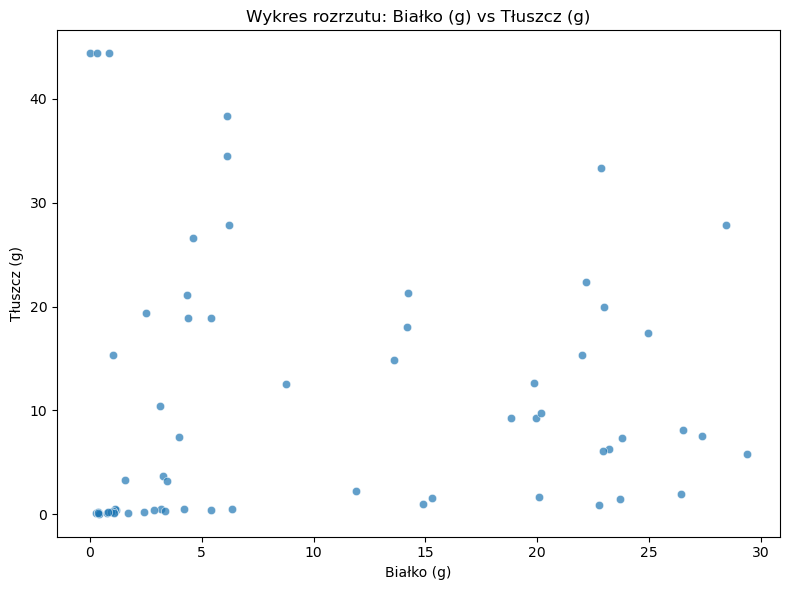

In [30]:
scatter_plot(food_df, ["Białko (g)", "Tłuszcz (g)"])

## Skalowanie danych

Algorytmy analizy skupień często wykorzystują odległości między obserwacjami.

Jeżeli zmienne mają różne skale, zmienne o większych wartościach mogą silniej wpływać na wynik grupowania.  
Dlatego przed modelowaniem przeskalujemy dane do wspólnego zakresu.

W tym przykładzie użyjemy `MinMaxScaler`, który przekształca wartości zmiennych do przedziału od 0 do 1.

In [31]:
# Skalowanie wartości predyktorów
# Przed wykonaniem skalowania tworzymy kopię ramki danych

scaled_food_df = food_df.copy()

min_max_scaler = MinMaxScaler()

scaled_food_df.loc[:, predictors] = min_max_scaler.fit_transform(
    scaled_food_df[predictors]
)

scaled_food_df[predictors].head()

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,0.028925,1.000000,0.001682,0.137961,0.267918,0.000000,1.000000,0.000000,0.0,0.659891,0.0,0.055102
"Cheese, cheddar",0.778244,0.750593,0.086616,1.000000,1.000000,0.031746,1.000000,0.100418,0.0,0.400000,0.0,0.859184
"Cheese, cream",0.209279,0.776109,0.154731,0.575835,0.253538,0.023810,1.000000,0.075314,0.0,1.000000,0.0,0.455102
"Cheese, feta",0.483553,0.478943,0.114647,1.000000,0.819692,0.166667,0.581395,0.623431,0.0,0.266667,0.0,1.000000
Mozzarella,0.754424,0.503105,0.061388,1.000000,0.861538,0.111111,0.832558,0.104603,0.0,0.266667,0.0,0.563265


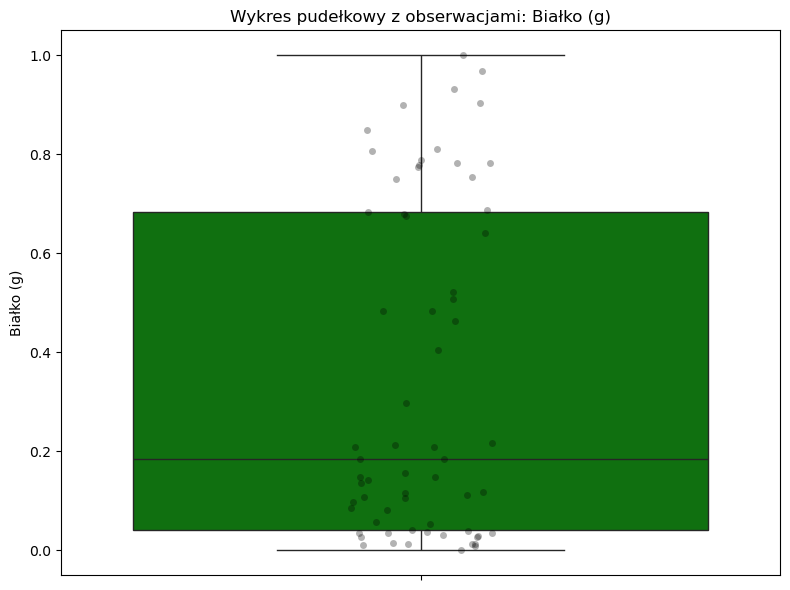

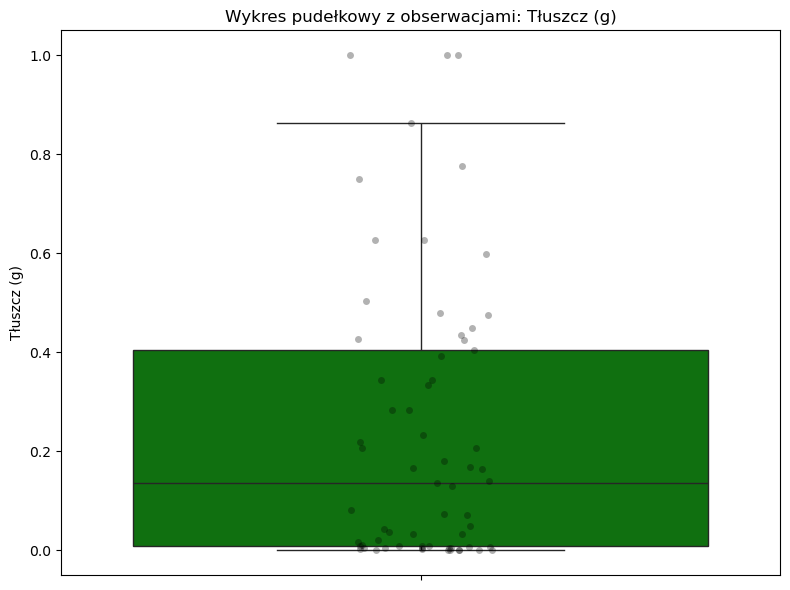

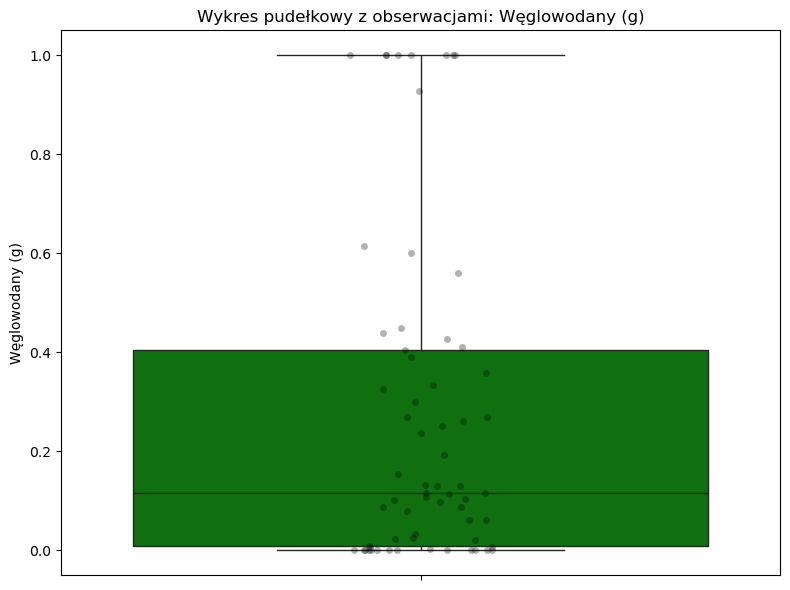

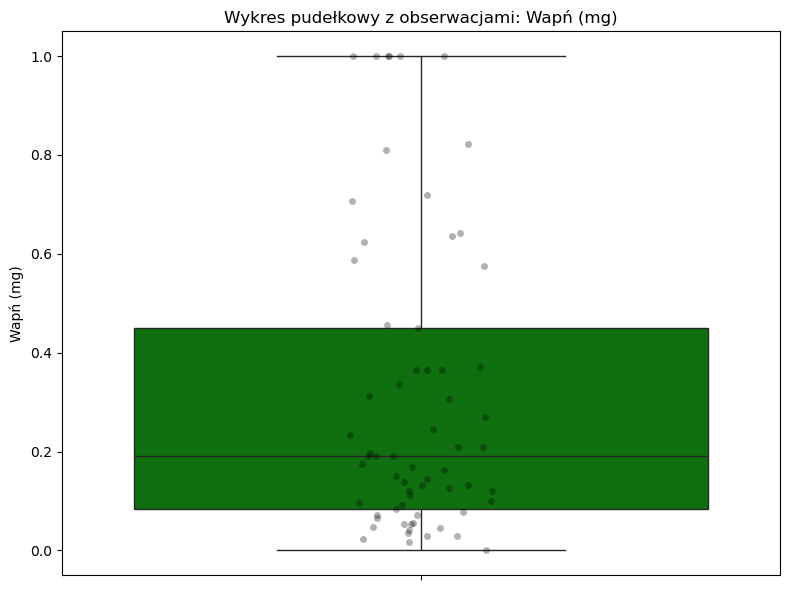

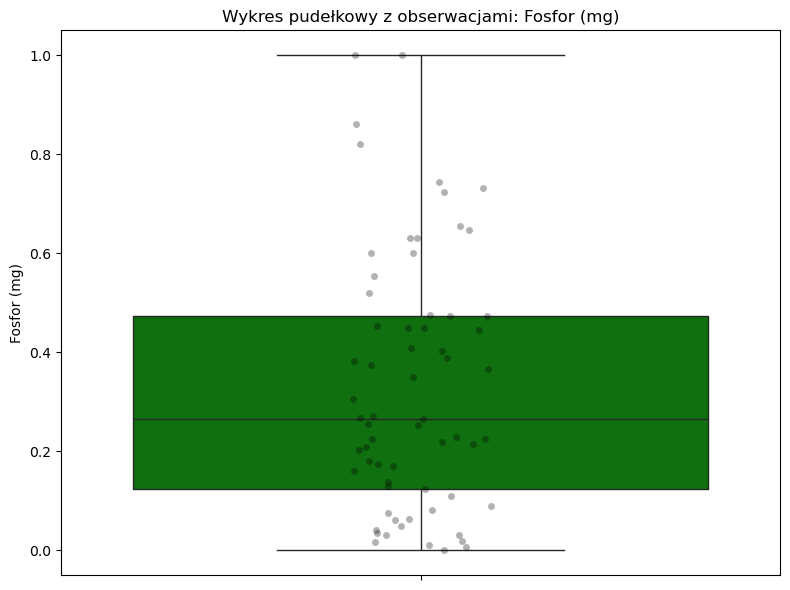

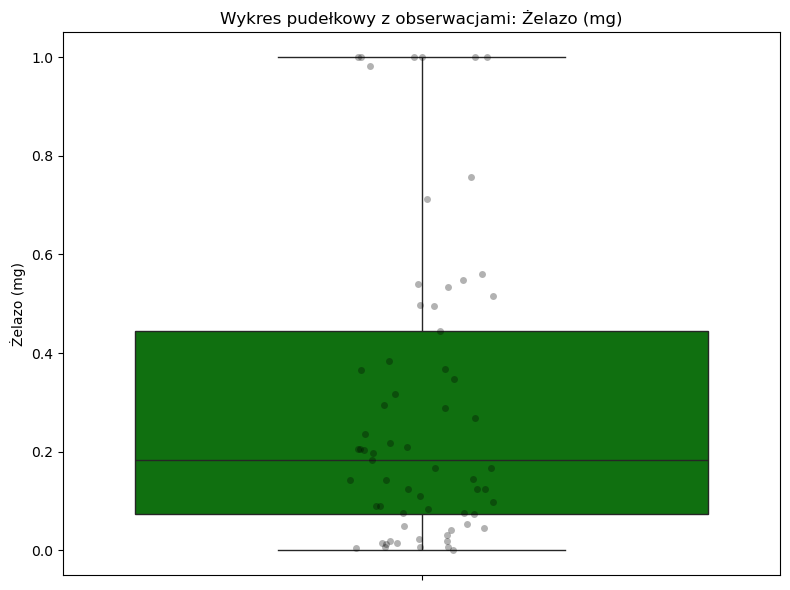

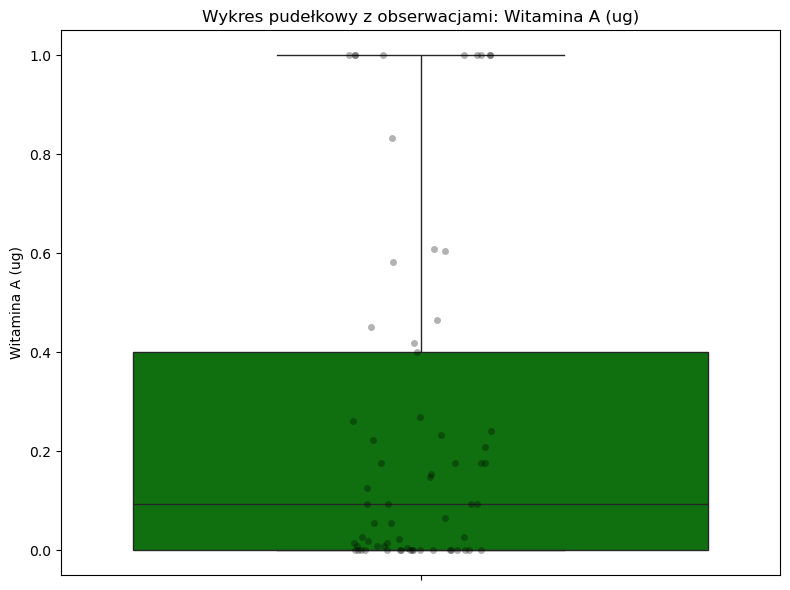

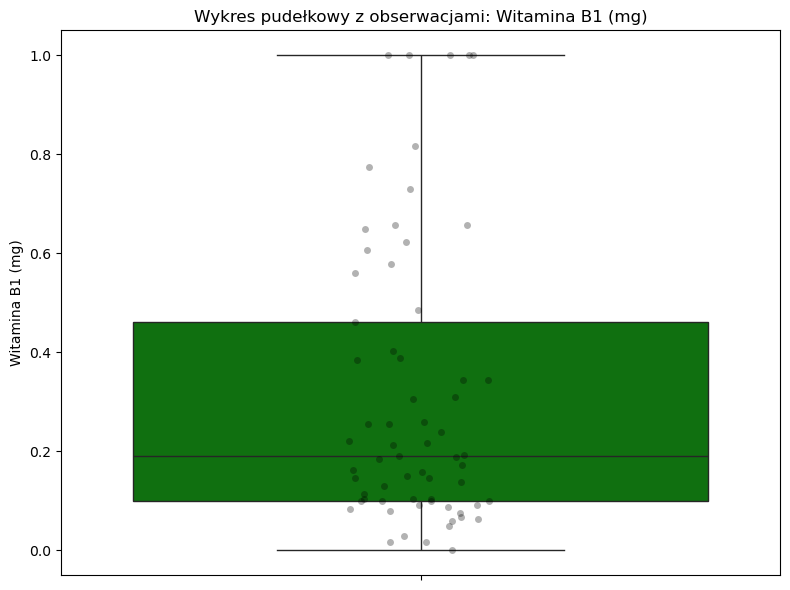

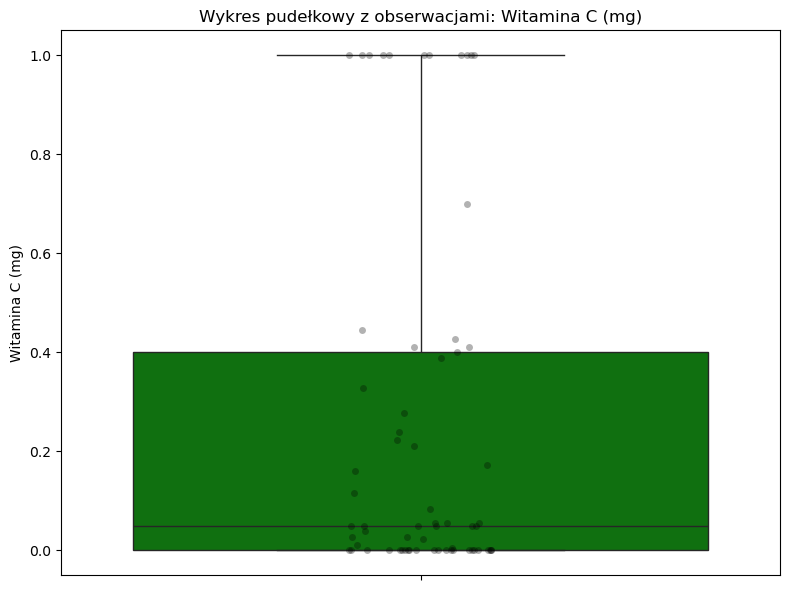

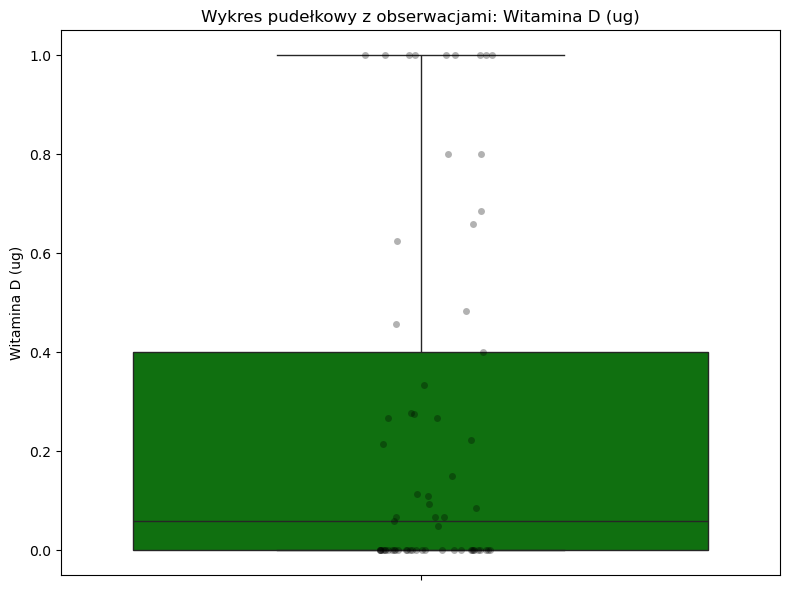

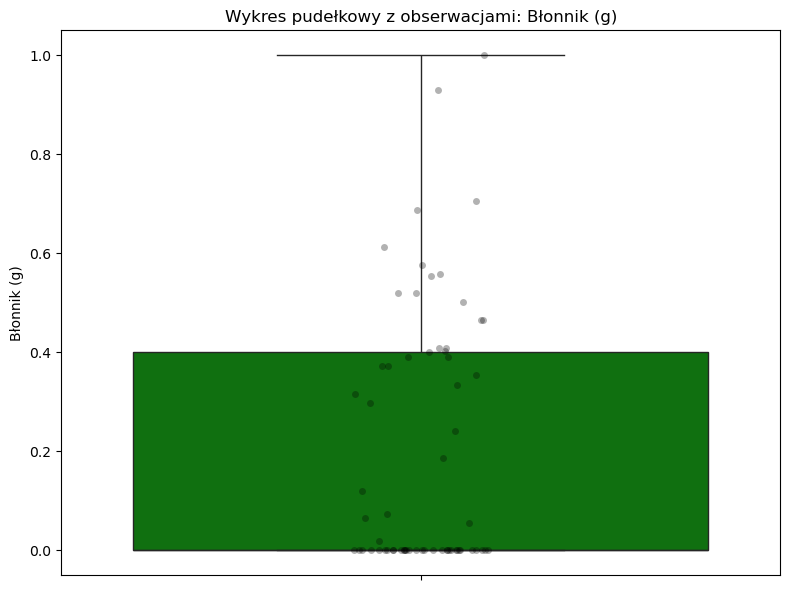

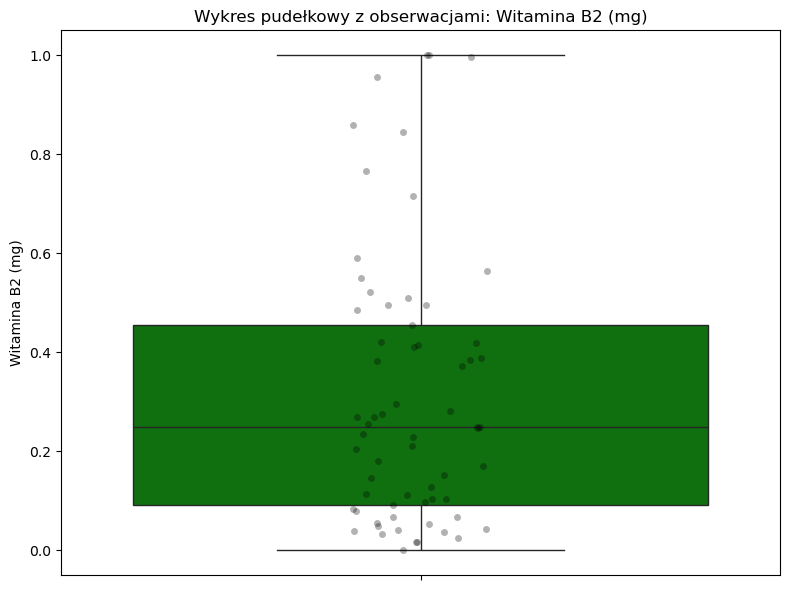

In [32]:
# Sprawdzenie rozkładów zmiennych po skalowaniu
plot_box_strip(scaled_food_df, predictors)

# Zadanie 3 -  Samodzielna analiza skupień produktów spożywczych

Dane zostały przygotowane do analizy skupień.

Na podstawie przygotowanych ramek:

- `food_df`,
- `scaled_food_df`,
- `predictors`

wykonaj samodzielną analizę skupień produktów spożywczych.

Wykorzystaj notebook ze zbiorem Iris jako wzorzec postępowania.

## Co należy zrobić?

1. Dobierz liczbę skupień, korzystając z co najmniej dwóch kryteriów, np.:
   - wykresu osypiska,
   - wskaźnika sylwetki,
   - Calinski-Harabasz Score,
   - Davies-Bouldin Score.

2. Zbuduj model analizy skupień wybraną metodą, np. KMeans lub metodą aglomeracyjną.

3. Oceń jakość otrzymanego podziału:
   - sprawdź liczności skupień,
   - oblicz wybrane miary jakości,
   - przygotuj wizualizację skupień za pomocą PCA lub t-SNE.

4. Zinterpretuj otrzymane skupienia:
   - czym różnią się grupy produktów,
   - które zmienne najlepiej opisują poszczególne skupienia,
   - jak można nazwać otrzymane grupy.

## Efekt końcowy

Przygotuj krótkie podsumowanie analizy, w którym wskażesz:

- wybraną metodę,
- wybraną liczbę skupień,
- najważniejsze wyniki oceny jakości,
- interpretację otrzymanych grup produktów.

In [33]:
# Biblioteki
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Dane wejściowe
X = scaled_food_df[predictors].copy()

X.head()

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,0.028925,1.000000,0.001682,0.137961,0.267918,0.000000,1.000000,0.000000,0.0,0.659891,0.0,0.055102
"Cheese, cheddar",0.778244,0.750593,0.086616,1.000000,1.000000,0.031746,1.000000,0.100418,0.0,0.400000,0.0,0.859184
"Cheese, cream",0.209279,0.776109,0.154731,0.575835,0.253538,0.023810,1.000000,0.075314,0.0,1.000000,0.0,0.455102
"Cheese, feta",0.483553,0.478943,0.114647,1.000000,0.819692,0.166667,0.581395,0.623431,0.0,0.266667,0.0,1.000000
Mozzarella,0.754424,0.503105,0.061388,1.000000,0.861538,0.111111,0.832558,0.104603,0.0,0.266667,0.0,0.563265


In [35]:
# Sprawdzenie różnych liczb skupień za pomocą kilku kryteriów: inertia, silhouette score
cluster_range = range(2, 11)

results = []

for k in cluster_range:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=10
    )
    
    labels = kmeans_model.fit_predict(X)
    
    results.append({
        "n_clusters": k,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette_score(X, labels)
    })

cluster_quality_df = pd.DataFrame(results)
cluster_quality_df

,n_clusters,inertia,silhouette_score
0,2,53.372792,0.273028
1,3,44.206859,0.285655
2,4,36.441994,0.275040
3,5,32.640299,0.254768
4,6,29.409709,0.251801
5,7,24.931103,0.278570
6,8,23.713177,0.258916
7,9,20.787922,0.295080
8,10,18.603642,0.306448


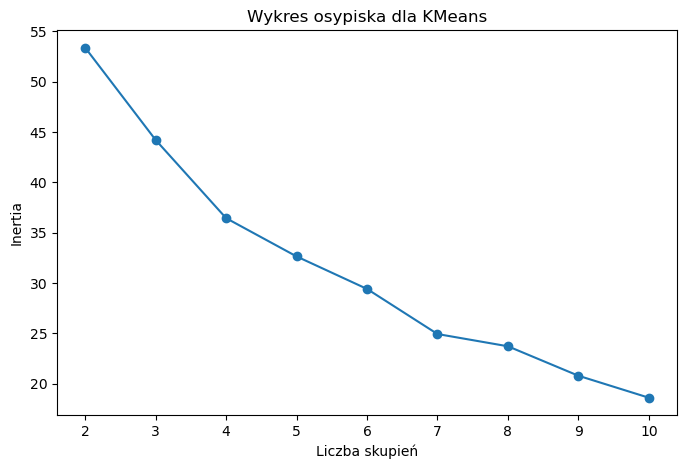

In [36]:
# Wykres osypiska
plt.figure(figsize=(8, 5))
plt.plot(cluster_quality_df["n_clusters"], cluster_quality_df["inertia"], marker="o")
plt.title("Wykres osypiska dla KMeans")
plt.xlabel("Liczba skupień")
plt.ylabel("Inertia")
plt.xticks(list(cluster_range))
plt.show()

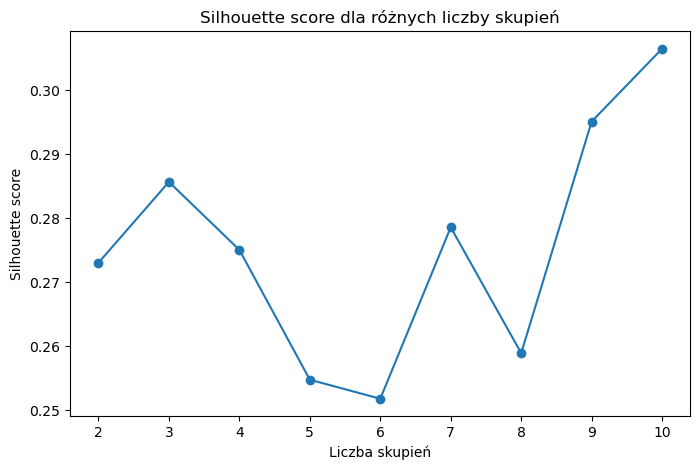

In [37]:
# Wykres Silhouette score
plt.figure(figsize=(8, 5))
plt.plot(cluster_quality_df["n_clusters"], cluster_quality_df["silhouette_score"], marker="o")
plt.title("Silhouette score dla różnych liczby skupień")
plt.xlabel("Liczba skupień")
plt.ylabel("Silhouette score")
plt.xticks(list(cluster_range))
plt.show()

# Komentarz
Do dalszej analizy wybrano **3 skupienia**. Decyzję podjęto na podstawie dwóch kryteriów: wykresu osypiska oraz silhouette score.

Na wykresie osypiska widać największy spadek wartości inertia dla małych liczby klastrów, szczególnie między 2 a 4 skupieniami. Po tym zakresie spadek jest mniej gwałtowny, dlatego wybór 3 skupień można uznać za kompromis między jakością podziału a prostotą interpretacji.

Wskaźnik silhouette score osiąga dla 3 skupień wartość **0.285655**, czyli jest to jeden z lepszych wyników dla analizowanego zakresu. Chociaż najwyższy wynik silhouette występuje dla 10 skupień, taki podział byłby mniej czytelny i trudniejszy do interpretacji merytorycznej. Z tego powodu wybrano **k = 3**.

In [38]:
# Wybrana liczba skupień, model Kmeans
chosen_k = 3

final_kmeans_model = KMeans(
    n_clusters=chosen_k,
    random_state=seed,
    n_init=10
)

food_df["cluster_kmeans"] = final_kmeans_model.fit_predict(X)

food_df["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    35
1    10
2    20
Name: count, dtype: int64

In [40]:
# Końcowe miary jakości modelu
labels = food_df["cluster_kmeans"]

final_metrics = pd.DataFrame({
    "method": ["KMeans"],
    "n_clusters": [chosen_k],
    "silhouette_score": [silhouette_score(X, labels)]
})

final_metrics

,method,n_clusters,silhouette_score
0,KMeans,3,0.285655


In [41]:
# Średnie wartości zmiennych w każdym skupieniu
cluster_profile = food_df.groupby("cluster_kmeans")[predictors].mean()

cluster_profile

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
cluster_kmeans,,,,,,,,,,,,
0,2.552857,7.559000,16.354254,52.106122,67.395670,0.803143,34.714286,0.077301,7.594286,0.010367,1.982889,0.089863
1,14.597000,26.707000,4.010000,110.857143,241.386056,0.704000,193.900000,0.039600,0.100000,0.982765,0.000000,0.269900
2,21.133124,7.602009,1.179426,24.757741,212.071350,1.911486,21.200000,0.104204,1.595000,0.737781,0.108547,0.229569


In [42]:
# Profil skupień na danych standaryzowanych
# Wartości dodatnie oznaczają cechy powyżej średniej, a ujemne cechy poniżej średniej
scaled_profile = scaled_food_df[predictors].copy()
scaled_profile["cluster_kmeans"] = food_df["cluster_kmeans"]

cluster_profile_scaled = scaled_profile.groupby("cluster_kmeans")[predictors].mean()

cluster_profile_scaled

,Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
cluster_kmeans,,,,,,,,,,,,
0,0.086871,0.169109,0.458425,0.306549,0.156051,0.207181,0.161462,0.302516,0.421905,0.006911,0.368580,0.169107
1,0.496722,0.601490,0.112404,0.658955,0.584335,0.180952,0.901860,0.144770,0.005556,0.655177,0.000000,0.536531
2,0.719140,0.170080,0.033060,0.142506,0.512176,0.500393,0.098605,0.415079,0.088611,0.491854,0.020177,0.454223


In [43]:
# Zmienne, które najbardziej odróżniają daną grupe od innych
for cluster_id in cluster_profile_scaled.index:
    print(f"\nSkupienie {cluster_id}")
    
    sorted_features = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    
    print("Najwyższe wartości:")
    display(sorted_features.head(5))
    
    print("Najniższe wartości:")
    display(sorted_features.tail(5))


Skupienie 0
Najwyższe wartości:


Węglowodany (g)     0.458425
Witamina C (mg)     0.421905
Błonnik (g)         0.368580
Wapń (mg)           0.306549
Witamina B1 (mg)    0.302516
Name: 0, dtype: float64

Najniższe wartości:


Witamina B2 (mg)    0.169107
Witamina A (ug)     0.161462
Fosfor (mg)         0.156051
Białko (g)          0.086871
Witamina D (ug)     0.006911
Name: 0, dtype: float64


Skupienie 1
Najwyższe wartości:


...

Żelazo (mg)         0.180952
Witamina B1 (mg)    0.144770
Węglowodany (g)     0.112404
Witamina C (mg)     0.005556
Błonnik (g)         0.000000
Name: 1, dtype: float64


Skupienie 2
Najwyższe wartości:


Białko (g)          0.719140
Fosfor (mg)         0.512176
Żelazo (mg)         0.500393
Witamina D (ug)     0.491854
Witamina B2 (mg)    0.454223
Name: 2, dtype: float64

Najniższe wartości:


Wapń (mg)          0.142506
Witamina A (ug)    0.098605
Witamina C (mg)    0.088611
Węglowodany (g)    0.033060
Błonnik (g)        0.020177
Name: 2, dtype: float64

Wyjaśniona wariancja przez PCA:
[0.34261855 0.17068892]
Suma wyjaśnionej wariancji: 0.5133074751062479


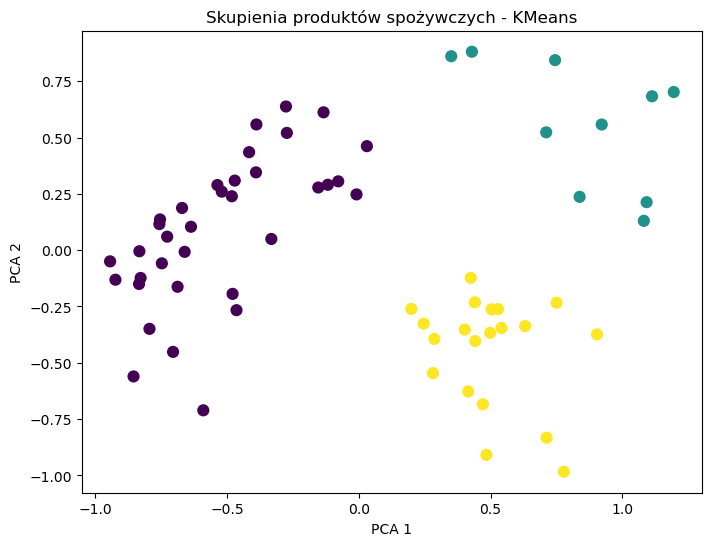

In [45]:
# PCA
pca = PCA(n_components=2, random_state=seed)
pca_result = pca.fit_transform(X)

food_df["pca_1"] = pca_result[:, 0]
food_df["pca_2"] = pca_result[:, 1]

print("Wyjaśniona wariancja przez PCA:")
print(pca.explained_variance_ratio_)
print("Suma wyjaśnionej wariancji:", pca.explained_variance_ratio_.sum())

# Wykres
plt.figure(figsize=(8, 6))

plt.scatter(
    food_df["pca_1"],
    food_df["pca_2"],
    c=food_df["cluster_kmeans"],
    cmap="viridis",
    s=60
)

plt.title("Skupienia produktów spożywczych - KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [46]:
# Nazwy dla skupień
cluster_names = {
    0: "Grupa 0",
    1: "Grupa 1",
    2: "Grupa 2"
}

food_df["cluster_name"] = food_df["cluster_kmeans"].map(cluster_names)

food_df[["cluster_kmeans", "cluster_name"]].head()

,cluster_kmeans,cluster_name
Butter,1,Grupa 1
"Cheese, cheddar",1,Grupa 1
"Cheese, cream",1,Grupa 1
"Cheese, feta",1,Grupa 1
Mozzarella,1,Grupa 1


In [47]:
for cluster_id in sorted(food_df["cluster_kmeans"].unique()):
    print(f"\nSkupienie {cluster_id}")
    display(food_df[food_df["cluster_kmeans"] == cluster_id].head(10))


Skupienie 0


,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg),cluster_kmeans,pca_1,pca_2,cluster_name
Cream,1049,123.0,3.13,10.390,4.73,107.0,95.000000,0.05,97.0,0.030000,0.9,0.074876,0.000000,0.194000,0,0.030936,0.461773,Grupa 0
Milk,1078,64.0,3.28,3.660,4.65,119.0,93.000000,0.05,33.0,0.038000,1.5,0.087967,0.347251,0.145155,0,-0.117262,0.290402,Grupa 0
Yogurt,1116,61.0,3.47,3.250,4.66,121.0,95.000000,0.05,27.0,0.029000,0.5,0.100000,0.000000,0.142000,0,-0.077749,0.305568,Grupa 0
Olive,4053,577.5,0.00,44.355,0.00,1.0,161.681142,0.56,0.0,0.050544,0.0,0.000000,0.000000,0.129330,0,-0.008409,0.247642,Grupa 0
Apples,9004,48.0,0.27,0.130,12.76,5.0,11.000000,0.07,2.0,0.019000,4.0,0.000000,1.300000,0.028000,0,-0.636424,0.103944,Grupa 0
Blackberries,9048,64.0,1.18,0.430,15.67,29.0,30.000000,0.80,6.0,0.029000,3.1,0.000000,5.000000,0.046000,0,-0.756375,0.115829,Grupa 0
Blueberries,9055,85.0,0.40,0.130,21.95,6.0,7.000000,0.39,2.0,0.020000,1.0,0.000000,2.200000,0.052000,0,-0.670304,0.187363,Grupa 0
Cherries,9070,63.0,1.06,0.200,16.01,13.0,21.000000,0.36,3.0,0.027000,7.0,0.000000,2.100000,0.033000,0,-0.726840,0.059953,Grupa 0
Grapefruit,9112,42.0,0.77,0.140,10.66,22.0,18.000000,0.08,58.0,0.043000,18.0,0.000000,1.600000,0.031000,0,-0.832260,-0.004788,Grupa 0
Kiwifruit,9148,61.0,1.14,0.520,14.66,34.0,60.438169,0.31,4.0,0.027000,18.0,0.000000,3.000000,0.025000,0,-0.943399,-0.049658,Grupa 0



Skupienie 1


,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg),cluster_kmeans,pca_1,pca_2,cluster_name
Butter,1001,577.5,0.85,44.355,0.06,24.000000,112.841563,0.02,215.0,0.005,0.0,0.989836,0.0,0.034,1,0.429306,0.881067,Grupa 1
"Cheese, cheddar",1009,404.0,22.87,33.310,3.09,167.714286,410.250000,0.14,215.0,0.029,0.0,0.600000,0.0,0.428,1,1.195116,0.702158,Grupa 1
"Cheese, cream",1017,350.0,6.15,34.440,5.52,97.000000,107.000000,0.11,215.0,0.023,0.0,1.500000,0.0,0.230,1,0.744997,0.843735,Grupa 1
"Cheese, feta",1019,264.0,14.21,21.280,4.09,167.714286,337.000000,0.65,125.0,0.154,0.0,0.400000,0.0,0.497,1,0.838058,0.236861,Grupa 1
Mozzarella,1026,300.0,22.17,22.350,2.19,167.714286,354.000000,0.44,179.0,0.030,0.0,0.400000,0.0,0.283,1,0.921924,0.557951,Grupa 1
Parmesan,1032,420.0,28.42,27.840,13.91,167.714286,410.250000,0.49,215.0,0.026,0.0,0.500000,0.0,0.358,1,1.112880,0.683251,Grupa 1
Egg,1128,196.0,13.61,14.840,0.83,62.000000,215.000000,1.89,215.0,0.044,0.0,1.500000,0.0,0.495,1,1.092266,0.213009,Grupa 1
Margarine,4585,577.5,0.31,44.355,0.77,10.000000,77.518997,0.04,215.0,0.009,0.1,0.937812,0.0,0.023,1,0.351036,0.861013,Grupa 1
Herring,15041,262.0,14.19,18.000,9.64,77.000000,89.000000,1.22,215.0,0.036,0.0,1.500000,0.0,0.139,1,0.711189,0.523144,Grupa 1
Mackerel,15048,156.0,23.19,6.300,0.00,167.714286,301.000000,2.04,130.0,0.040,0.9,1.500000,0.0,0.212,1,1.081677,0.130241,Grupa 1



Skupienie 2


,ID,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg),cluster_kmeans,pca_1,pca_2,cluster_name
Codfish,15017,105.0,22.76,0.86,0.00,21.0,260.0,0.49,14.0,0.087,1.0,1.200000,0.000000,0.079000,2,0.541972,-0.345222,Grupa 2
Perch,15057,79.0,15.31,1.54,0.00,28.0,248.0,0.22,12.0,0.040,0.0,1.200000,0.000000,0.048000,2,0.425055,-0.122825,Grupa 2
Salmon,15082,184.0,27.36,7.50,0.00,46.0,298.0,0.71,32.0,0.115,1.0,1.500000,0.000000,0.249360,2,0.904071,-0.373892,Grupa 2
Tuna,15124,186.0,26.53,8.08,0.00,4.0,267.0,0.65,5.0,0.017,0.0,0.414277,0.000000,0.420586,2,0.631591,-0.337168,Grupa 2
Mussel,15164,86.0,11.90,2.24,3.69,26.0,197.0,3.80,48.0,0.160,8.0,1.500000,0.000000,0.210000,2,0.470945,-0.684415,Grupa 2
Octopus,15166,82.0,14.91,1.04,2.20,53.0,186.0,3.80,45.0,0.030,5.0,1.500000,0.000000,0.040000,2,0.498860,-0.367139,Grupa 2
Oyster,15168,199.0,8.77,12.58,11.62,62.0,159.0,3.80,90.0,0.150,3.8,0.164711,0.000000,0.262642,2,0.199582,-0.260817,Grupa 2
Crab,15227,115.0,23.72,1.51,0.00,33.0,128.0,2.88,52.0,0.097,7.2,1.027228,2.170932,0.082012,2,0.281543,-0.545811,Grupa 2
Lobster,15228,143.0,26.41,1.94,3.12,63.0,229.0,1.41,6.0,0.009,2.1,0.723910,0.000000,0.195220,2,0.528387,-0.261722,Grupa 2
Trout,15241,168.0,23.80,7.38,0.00,30.0,270.0,0.36,100.0,0.143,2.9,1.500000,0.000000,0.107000,2,0.751138,-0.233382,Grupa 2


In [49]:
# Końcowe nazwy
cluster_names = {
    0: "Produkty węglowodanowe, owocowo-warzywne",
    1: "Produkty mleczne i bogate w witaminy A",
    2: "Produkty rybne i owoce morza"
}

food_df["cluster_name"] = food_df["cluster_kmeans"].map(cluster_names)

food_df[["cluster_kmeans", "cluster_name"]].head()

,cluster_kmeans,cluster_name
Butter,1,Produkty mleczne i bogate w witaminy A
"Cheese, cheddar",1,Produkty mleczne i bogate w witaminy A
"Cheese, cream",1,Produkty mleczne i bogate w witaminy A
"Cheese, feta",1,Produkty mleczne i bogate w witaminy A
Mozzarella,1,Produkty mleczne i bogate w witaminy A


# Wnioski
## Interpretacja skupień

**Skupienie 0** obejmuje największą grupę produktów, liczącą 35 obserwacji. Produkty w tej grupie mają relatywnie wyższe wartości węglowodanów, witaminy C i błonnika. Jednocześnie mają niską zawartość białka oraz witaminy D. Wśród przykładów znajdują się między innymi owoce, produkty mleczne o niższej zawartości tłuszczu.

**Skupienie 1** liczy 10 obserwacji. Charakteryzuje się wysokimi wartościami witaminy A, wapnia, witaminy D, tłuszczu oraz fosforu. Do tej grupy należą między innymi masło, sery, margaryna, jajko oraz tłuste ryby.

**Skupienie 2** liczy 20 obserwacji. Produkty w tej grupie mają najwyższe wartości białka, fosforu, żelaza, witaminy D i witaminy B2. Jednocześnie mają bardzo niską zawartość węglowodanów i błonnika. W tej grupie dominują ryby oraz owoce morza.

## Podsumowanie analizy

W analizie zastosowano metodę **KMeans** oraz wybrano **3 skupienia**. Liczbę klastrów dobrano na podstawie wykresu osypiska i silhouette score. Ostateczny wynik silhouette score dla modelu z 3 skupieniami wyniósł 0.29.

Podział jest umiarkowanie dobry, ale interpretowalny. Wizualizacja PCA pokazuje, że grupy są częściowo rozdzielone, chociaż nie są idealnie odseparowane. Dwie pierwsze składowe PCA wyjaśniają łącznie około 51.33% wariancji, więc wykres pokazuje znaczną, ale nie pełną część informacji zawartej w danych.

Otrzymane skupienia mają sens merytoryczny. Pierwsza grupa obejmuje głównie produkty bardziej węglowodanowe. Druga grupa obejmuje produkty tłuste, mleczne. Trzecia grupa obejmuje produkty wysokobiałkowe, głównie ryby i owoce morza.

# Zadanie 4 - Analiza skupień po redukcji wymiarów

W przygotowanym notebooku jedna z decyzji analitycznych polegała na usunięciu zmiennej `Energia (kcal)`, ponieważ była silnie powiązana z innymi zmiennymi, zwłaszcza z zawartością tłuszczu.

W tym zadaniu sprawdzisz inne podejście: zamiast ręcznie usuwać silnie powiązane zmienne, zastosujesz redukcję wymiarów, a następnie wykonasz analizę skupień na uzyskanych składowych lub czynnikach.

## Co należy zrobić?

1. Przygotuj dane liczbowe do analizy.
2. Nie usuwaj zmiennej `Energia (kcal)` na podstawie samej korelacji.
3. Sprawdź, czy struktura korelacji między zmiennymi uzasadnia zastosowanie redukcji wymiarów:
   - oblicz miarę KMO,
   - wykonaj test sferyczności Bartletta.
4. Wykonaj PCA.
5. Wybierz liczbę składowych na podstawie:
   - wartości własnych,
   - procentu wyjaśnionej wariancji,
   - wykresu osypiska,
   - interpretowalności składowych.
6. Zapisz wartości składowych dla obserwacji.
7. Wykonaj analizę skupień na uzyskanych składowych.
8. Porównaj wyniki z analizą skupień wykonaną na oryginalnych zmiennych.

## Co należy porównać?

Porównaj oba podejścia pod względem:

- liczby i liczności skupień,
- wartości wskaźnika sylwetki,
- wartości Calinski-Harabasz Score,
- wartości Davies-Bouldin Score,
- interpretowalności profili skupień,
- zgodności lub podobieństwa uzyskanych podziałów.

Do porównania dwóch różnych podziałów możesz wykorzystać Adjusted Rand Index, traktując jeden model jako punkt odniesienia.

## Pytania do interpretacji

1. Czy KMO i test Bartletta sugerują, że redukcja wymiarów ma sens?
2. Ile składowych lub czynników warto zachować?
3. Jak można zinterpretować uzyskane składowe/czynniki?
4. Czy analiza skupień na skorach daje bardziej czytelne grupy niż analiza na oryginalnych zmiennych?
5. Czy wyniki obu podejść są podobne?
6. Które podejście jest lepsze: analiza na oryginalnych zmiennych czy analiza po redukcji wymiarów?
7. Czy usunięcie zmiennej `Energia (kcal)` było konieczne, czy redukcja wymiarów lepiej rozwiązuje problem współzależności zmiennych?

## Uwaga metodyczna

KMO i test Bartletta służą do oceny, czy dane mają strukturę korelacyjną, która uzasadnia zastosowanie analizy PCA lub podobnych metod redukcji wymiarów.

Dopiero po redukcji wymiarów wykonujemy analizę skupień i oceniamy jej jakość za pomocą miar typowych dla segmentacji.

In [63]:
from scipy.stats import chi2
from sklearn.metrics import adjusted_rand_score

numeric_columns = food_df.select_dtypes(include=["number"]).columns

# Usuwamy kolumny techniczne, jeżeli istnieją
columns_to_remove = ["ID", "cluster_kmeans", "pca_1", "pca_2"]

numeric_columns = [col for col in numeric_columns if col not in columns_to_remove]

X_numeric = food_df[numeric_columns].copy()

X_numeric.head()

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg),cluster_kmeans_pca,cluster_kmeans_original
Butter,577.5,0.85,44.355,0.06,24.000000,112.841563,0.02,215.0,0.005,0.0,0.989836,0.0,0.034,2,1
"Cheese, cheddar",404.0,22.87,33.310,3.09,167.714286,410.250000,0.14,215.0,0.029,0.0,0.600000,0.0,0.428,0,1
"Cheese, cream",350.0,6.15,34.440,5.52,97.000000,107.000000,0.11,215.0,0.023,0.0,1.500000,0.0,0.230,0,1
"Cheese, feta",264.0,14.21,21.280,4.09,167.714286,337.000000,0.65,125.0,0.154,0.0,0.400000,0.0,0.497,0,1
Mozzarella,300.0,22.17,22.350,2.19,167.714286,354.000000,0.44,179.0,0.030,0.0,0.400000,0.0,0.283,0,1


In [51]:
# Skalowanie danych
scaler = MinMaxScaler()

X_scaled_pca = pd.DataFrame(
    scaler.fit_transform(X_numeric),
    columns=X_numeric.columns,
    index=X_numeric.index
)

X_scaled_pca.head()

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
Butter,1.000000,0.028925,1.000000,0.001682,0.137961,0.267918,0.000000,1.000000,0.000000,0.0,0.659891,0.0,0.055102
"Cheese, cheddar",0.691006,0.778244,0.750593,0.086616,1.000000,1.000000,0.031746,1.000000,0.100418,0.0,0.400000,0.0,0.859184
"Cheese, cream",0.594835,0.209279,0.776109,0.154731,0.575835,0.253538,0.023810,1.000000,0.075314,0.0,1.000000,0.0,0.455102
"Cheese, feta",0.441674,0.483553,0.478943,0.114647,1.000000,0.819692,0.166667,0.581395,0.623431,0.0,0.266667,0.0,1.000000
Mozzarella,0.505788,0.754424,0.503105,0.061388,1.000000,0.861538,0.111111,0.832558,0.104603,0.0,0.266667,0.0,0.563265


In [52]:
# Obliczenie miary KMO, które sprawdza, czy dane mają strukturę korelacyjną uzasadniającą redukcję wymiarów
def calculate_kmo(data):
    corr = data.corr().values
    inv_corr = np.linalg.inv(corr)
    
    partial_corr = np.zeros(corr.shape)
    
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if i == j:
                partial_corr[i, j] = 0
            else:
                partial_corr[i, j] = -inv_corr[i, j] / np.sqrt(inv_corr[i, i] * inv_corr[j, j])
    
    corr_squared = corr ** 2
    partial_corr_squared = partial_corr ** 2
    
    np.fill_diagonal(corr_squared, 0)
    
    kmo_value = corr_squared.sum() / (corr_squared.sum() + partial_corr_squared.sum())
    
    return kmo_value

kmo_value = calculate_kmo(X_scaled_pca)

kmo_value

np.float64(0.5843331814243589)

In [53]:
# Test sferyczności Bartletta. Test sprawdza, czy macierz korelacji różni się istotnie od macierzy jednostkowej
def bartlett_sphericity_test(data):
    n, p = data.shape
    corr_matrix = data.corr().values
    
    det_corr = np.linalg.det(corr_matrix)
    
    chi_square_value = -(n - 1 - (2 * p + 5) / 6) * np.log(det_corr)
    degrees_of_freedom = p * (p - 1) / 2
    p_value = chi2.sf(chi_square_value, degrees_of_freedom)
    
    return chi_square_value, degrees_of_freedom, p_value

bartlett_chi2, bartlett_df, bartlett_p = bartlett_sphericity_test(X_scaled_pca)

pd.DataFrame({
    "KMO": [kmo_value],
    "Bartlett_chi2": [bartlett_chi2],
    "Bartlett_df": [bartlett_df],
    "Bartlett_p_value": [bartlett_p]
})

,KMO,Bartlett_chi2,Bartlett_df,Bartlett_p_value
0,0.584333,610.292156,78.0,1.686738e-83


In [54]:
# PCA
pca_full = PCA()
pca_full.fit(X_scaled_pca)

pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_))],
    "eigenvalue": pca_full.explained_variance_,
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_)
})

pca_summary

,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,PC1,0.415299,0.327523,0.327523
1,PC2,0.243683,0.192179,0.519702
2,PC3,0.166718,0.131481,0.651183
3,PC4,0.137913,0.108764,0.759947
4,PC5,0.082578,0.065124,0.825072
5,PC6,0.070218,0.055377,0.880449
6,PC7,0.043823,0.034561,0.915010
7,PC8,0.035624,0.028095,0.943105
8,PC9,0.031524,0.024861,0.967965
9,PC10,0.020613,0.016256,0.984222


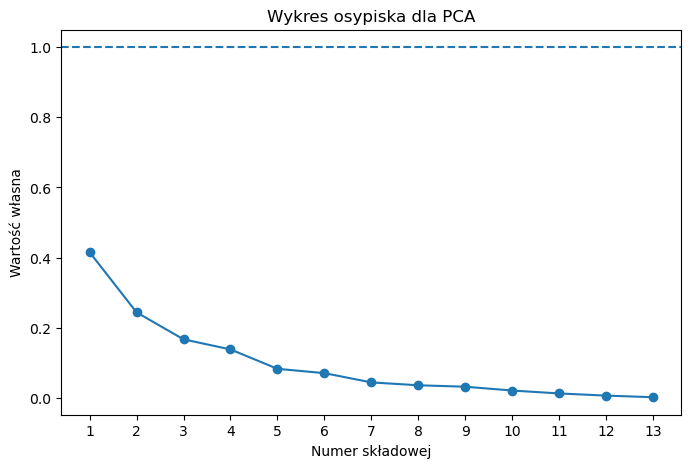

In [55]:
# Wykres osypiska dla PCA
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca_full.explained_variance_) + 1),
    pca_full.explained_variance_,
    marker="o"
)

plt.axhline(y=1, linestyle="--")

plt.title("Wykres osypiska dla PCA")
plt.xlabel("Numer składowej")
plt.ylabel("Wartość własna")
plt.xticks(range(1, len(pca_full.explained_variance_) + 1))
plt.show()

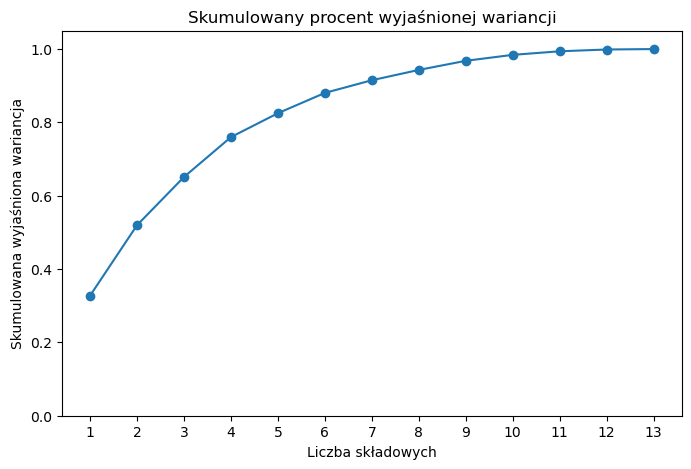

In [56]:
# WYkres procenty wyjaśnionej wariancji przez składowe PCA
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    np.cumsum(pca_full.explained_variance_ratio_),
    marker="o"
)

plt.title("Skumulowany procent wyjaśnionej wariancji")
plt.xlabel("Liczba składowych")
plt.ylabel("Skumulowana wyjaśniona wariancja")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.show()

In [57]:
# Wybór liczb składowych PCA
n_components = 4

pca_model = PCA(n_components=n_components, random_state=seed)

pca_components = pca_model.fit_transform(X_scaled_pca)

pca_components_df = pd.DataFrame(
    pca_components,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=food_df.index
)

pca_components_df.head()

,PC1,PC2,PC3,PC4
Butter,0.605604,0.851098,0.672842,-0.286474
"Cheese, cheddar",1.284684,0.510171,0.340237,0.538002
"Cheese, cream",0.823011,0.551932,0.769299,0.034807
"Cheese, feta",0.862341,0.141116,-0.019786,0.639948
Mozzarella,0.966678,0.334411,0.326247,0.413764


In [58]:
# Które zmienne najsilniej wpływają na składowe PCA
pca_loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=X_scaled_pca.columns
)

pca_loadings

,PC1,PC2,PC3,PC4
Energia (kcal),0.202435,0.470590,-0.230070,-0.009322
Białko (g),0.404007,-0.286634,-0.198990,-0.028443
Tłuszcz (g),0.228464,0.395728,-0.075737,0.018599
Węglowodany (g),-0.217649,0.445379,-0.302783,0.123689
Wapń (mg),0.151106,0.220409,0.168053,0.512933
Fosfor (mg),0.343763,-0.053107,-0.132384,0.124213
Żelazo (mg),0.113066,-0.193246,-0.429332,0.292187
Witamina A (ug),0.253158,0.202966,0.535327,0.413409
Witamina B1 (mg),-0.039740,-0.287090,-0.301286,0.361520
Witamina C (mg),-0.395215,-0.267066,0.221868,0.435861


In [59]:
# Model Kmeans dla PCA
# Dla porównania z poprzednim zadaniem zostawiamy 3 skupienia
k_pca = 3

kmeans_pca = KMeans(
    n_clusters=k_pca,
    random_state=seed,
    n_init=10
)

food_df["cluster_kmeans_pca"] = kmeans_pca.fit_predict(pca_components_df)

food_df["cluster_kmeans_pca"].value_counts().sort_index()

cluster_kmeans_pca
0    28
1    24
2    13
Name: count, dtype: int64

In [60]:
# Miara jakości dla modelu składowych PCA
labels_pca = food_df["cluster_kmeans_pca"]

pca_metrics = pd.DataFrame({
    "method": ["KMeans po PCA"],
    "n_clusters": [k_pca],
    "silhouette_score": [silhouette_score(pca_components_df, labels_pca)],
    "calinski_harabasz_score": [calinski_harabasz_score(pca_components_df, labels_pca)],
    "davies_bouldin_score": [davies_bouldin_score(pca_components_df, labels_pca)]
})

pca_metrics

,method,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,KMeans po PCA,3,0.370126,34.441641,1.057154


In [61]:
# Kmeans na oryginalnych zmiennych
X_original = scaled_food_df[predictors].copy()

kmeans_original = KMeans(
    n_clusters=3,
    random_state=seed,
    n_init=10
)

food_df["cluster_kmeans_original"] = kmeans_original.fit_predict(X_original)

labels_original = food_df["cluster_kmeans_original"]

original_metrics = pd.DataFrame({
    "method": ["KMeans na oryginalnych zmiennych"],
    "n_clusters": [3],
    "silhouette_score": [silhouette_score(X_original, labels_original)],
    "calinski_harabasz_score": [calinski_harabasz_score(X_original, labels_original)],
    "davies_bouldin_score": [davies_bouldin_score(X_original, labels_original)]
})

original_metrics

,method,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,KMeans na oryginalnych zmiennych,3,0.285655,21.817674,1.323901


In [64]:
# Porównanie onu podejść i obliczenie ARI
comparison_metrics = pd.concat(
    [original_metrics, pca_metrics],
    ignore_index=True
)

ari_between_models = adjusted_rand_score(
    food_df["cluster_kmeans_original"],
    food_df["cluster_kmeans_pca"]
)

comparison_metrics["ARI_vs_other_model"] = [ari_between_models, ari_between_models]

comparison_metrics

,method,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,ARI_vs_other_model
0,KMeans na oryginalnych zmiennych,3,0.285655,21.817674,1.323901,0.527514
1,KMeans po PCA,3,0.370126,34.441641,1.057154,0.527514


In [65]:
# Porównujemy liczności skupień w obu podejściach
cluster_counts_comparison = pd.DataFrame({
    "original_variables": food_df["cluster_kmeans_original"].value_counts().sort_index(),
    "after_pca": food_df["cluster_kmeans_pca"].value_counts().sort_index()
})

cluster_counts_comparison

,original_variables,after_pca
0,35,28
1,10,24
2,20,13


In [66]:
# Tabela kontyngencji
pd.crosstab(
    food_df["cluster_kmeans_original"],
    food_df["cluster_kmeans_pca"],
    rownames=["KMeans na oryginalnych zmiennych"],
    colnames=["KMeans po PCA"]
)

KMeans po PCA,0,1,2
KMeans na oryginalnych zmiennych,,,
0,0,24,11
1,8,0,2
2,20,0,0


In [67]:
# Interpretacja skupienia po PCA na podstawie średnich wartości oryginalnych zmiennych
pca_cluster_profile = food_df.groupby("cluster_kmeans_pca")[numeric_columns].mean()

pca_cluster_profile

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg),cluster_kmeans_pca,cluster_kmeans_original
cluster_kmeans_pca,,,,,,,,,,,,,,,
0,200.283164,20.266874,11.800007,2.244947,56.061652,230.890250,1.614633,69.035714,0.088074,1.171429,0.809129,0.077533,0.258335,0.0,1.714286
1,55.750000,1.962083,1.167500,10.868750,43.696429,44.340305,0.648750,36.541667,0.086833,10.850000,0.007832,2.173635,0.075131,1.0,0.000000
2,451.923077,3.340000,25.019615,24.029146,62.230769,114.233977,0.969231,59.076923,0.048888,0.423077,0.161733,1.325681,0.107618,2.0,0.153846


In [69]:
# Profil skupień po PCA na danych skalowanych. To ułatwia wskazanie, które cechy są wysokie lub niskie w każdym skupieniu
scaled_profile_pca = X_scaled_pca.copy()
scaled_profile_pca["cluster_kmeans_pca"] = food_df["cluster_kmeans_pca"]

pca_cluster_profile_scaled = scaled_profile_pca.groupby("cluster_kmeans_pca").mean()

pca_cluster_profile_scaled

,Energia (kcal),Białko (g),Tłuszcz (g),Węglowodany (g),Wapń (mg),Fosfor (mg),Żelazo (mg),Witamina A (ug),Witamina B1 (mg),Witamina C (mg),Witamina D (ug),Błonnik (g),Witamina B2 (mg)
cluster_kmeans_pca,,,,,,,,,,,,,
0,0.328198,0.689662,0.264875,0.062928,0.330276,0.558499,0.421860,0.321096,0.347591,0.065079,0.539419,0.014412,0.512929
1,0.070793,0.066768,0.024783,0.304661,0.256105,0.099299,0.166336,0.169961,0.342399,0.602778,0.005221,0.404036,0.139044
2,0.776355,0.113657,0.563387,0.673560,0.367280,0.271345,0.251119,0.274776,0.183632,0.023504,0.107822,0.246418,0.205343


In [70]:
# Cechy charakterystyczne dla danego skupienia po PCA
for cluster_id in pca_cluster_profile_scaled.index:
    print(f"\nSkupienie {cluster_id} po PCA")
    
    sorted_features = pca_cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    
    print("Najwyższe wartości:")
    display(sorted_features.head(5))
    
    print("Najniższe wartości:")
    display(sorted_features.tail(5))


Skupienie 0 po PCA
Najwyższe wartości:


Białko (g)          0.689662
Fosfor (mg)         0.558499
Witamina D (ug)     0.539419
Witamina B2 (mg)    0.512929
Żelazo (mg)         0.421860
Name: 0, dtype: float64

Najniższe wartości:


Witamina A (ug)    0.321096
Tłuszcz (g)        0.264875
Witamina C (mg)    0.065079
Węglowodany (g)    0.062928
Błonnik (g)        0.014412
Name: 0, dtype: float64


Skupienie 1 po PCA
Najwyższe wartości:


...

Fosfor (mg)        0.099299
Energia (kcal)     0.070793
Białko (g)         0.066768
Tłuszcz (g)        0.024783
Witamina D (ug)    0.005221
Name: 1, dtype: float64


Skupienie 2 po PCA
Najwyższe wartości:


Energia (kcal)     0.776355
Węglowodany (g)    0.673560
Tłuszcz (g)        0.563387
Wapń (mg)          0.367280
Witamina A (ug)    0.274776
Name: 2, dtype: float64

Najniższe wartości:


Witamina B2 (mg)    0.205343
Witamina B1 (mg)    0.183632
Białko (g)          0.113657
Witamina D (ug)     0.107822
Witamina C (mg)     0.023504
Name: 2, dtype: float64

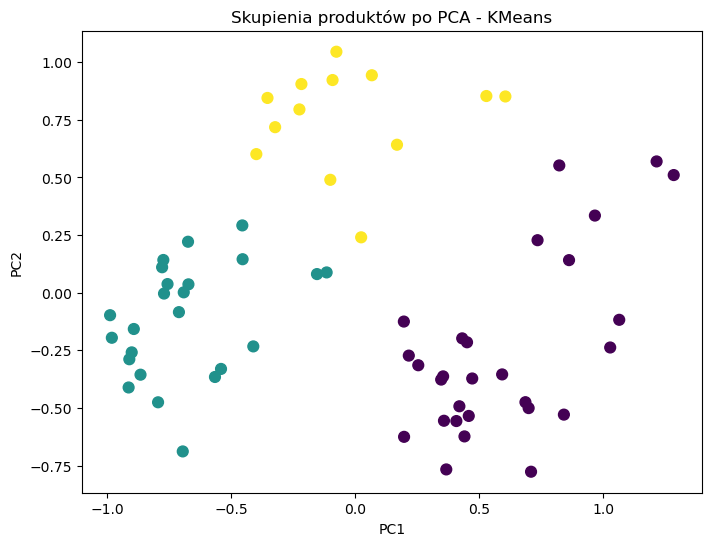

In [71]:
# Wykres skupienia po PCA
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_components_df["PC1"],
    pca_components_df["PC2"],
    c=food_df["cluster_kmeans_pca"],
    cmap="viridis",
    s=60
)

plt.title("Skupienia produktów po PCA - KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Wnioski końcowe

Miara KMO wyniosła 0.58, co oznacza akceptowalny, choć umiarkowany poziom dopasowania danych do redukcji wymiarów. Test sferyczności Bartletta był istotny statystycznie. Oznacza to, że zmienne są ze sobą istotnie skorelowane, więc zastosowanie PCA jest uzasadnione.

Na podstawie wartości własnych, wykresu osypiska, skumulowanego procentu wyjaśnionej wariancji oraz interpretowalności wybrano **4 składowe PCA**. Pierwsze 4 składowe wyjaśniają łącznie około 75.99% wariancji, co oznacza, że zachowują dużą część informacji zawartej w pierwotnych zmiennych.

Model KMeans wykonany na składowych PCA utworzył 3 skupienia o licznościach: 28, 24 i 13. W porównaniu z modelem na oryginalnych zmiennych, gdzie liczności wynosiły 35, 10 i 20, podział po PCA jest bardziej równomierny.

Analiza po PCA uzyskała lepsze wartości miar jakości:
- silhouette score wzrósł do 0.37,
- Calinski-Harabasz Score wzrósł do 34.44,
- Davies-Bouldin Score spadł do 1.06.

Oznacza to, że skupienia po PCA są bardziej zwarte i lepiej odseparowane niż skupienia uzyskane na oryginalnych zmiennych.

Podziały uzyskane obiema metodami są częściowo podobne, ale nie identyczne. Wartość ARI między nimi wyniosła 0.53, co wskazuje na umiarkowaną zgodność. PCA zmieniło więc strukturę podziału, ale nie całkowicie.

Skupienie 0 po PCA obejmuje produkty o wysokiej zawartości białka, fosforu, witaminy D, witaminy B2 i żelaza.

Skupienie 1 po PCA obejmuje produkty o wyższej zawartości witaminy C, błonnika i węglowodanów, a jednocześnie bardzo niskiej zawartości tłuszczu, energii i witaminy D.

Skupienie 2 po PCA charakteryzuje się wysoką energią, tłuszczem i węglowodanami.

Na podstawie wyników można uznać, że redukcja wymiarów PCA była korzystnym rozwiązaniem. Pozwoliła zachować zmienną `Energia (kcal)`, ograniczyć problem współzależności zmiennych i poprawić jakość klasteryzacji.

## Odpowiedzi na pytania do interpretacji

**Czy KMO i test Bartletta sugerują, że redukcja wymiarów ma sens?**

Tak. KMO wyniosło 0.58, czyli jest na poziomie akceptowalnym, choć umiarkowanym. Test Bartletta był istotny statystyczni. Oznacza to, że między zmiennymi występują istotne korelacje, więc redukcja wymiarów ma sens.

**Ile składowych lub czynników warto zachować?**

Warto zachować 4 składowe PCA. Wyjaśniają one łącznie około 76% wariancji, co jest dobrym wynikiem przy redukcji liczby zmiennych z 13 do 4. Dodatkowo wybór 4 składowych jest uzasadniony wykresem osypiska i interpretowalnością składowych.

**Jak można zinterpretować uzyskane składowe/czynniki?**

Na podstawie ładunków PCA można przyjąć, że:

- **PC1** opisuje głównie produkty bogate w białko, witaminę D, fosfor i witaminę B2, a po przeciwnej stronie produkty bogatsze w witaminę C, błonnik i węglowodany.
- **PC2** wiąże się głównie z energią, węglowodanami i tłuszczem.
- **PC3** jest związana przede wszystkim z witaminą A i witaminą D, a przeciwnie z żelazem i węglowodanami.
- **PC4** wiąże się głównie z wapniem, witaminą C, witaminą A oraz witaminą B1.

**Czy analiza skupień na skorach daje bardziej czytelne grupy niż analiza na oryginalnych zmiennych?**

Tak, w tym przypadku analiza po PCA daje bardziej czytelne i lepiej ocenione grupy. Skupienia po PCA mają lepsze wartości wszystkich głównych miar jakości: wyższy silhouette score, wyższy Calinski-Harabasz Score i niższy Davies-Bouldin Score.

**Czy wyniki obu podejść są podobne?**

Są częściowo podobne, ale nie identyczne. ARI między podziałem na oryginalnych zmiennych a podziałem po PCA pokazuje umiarkowaną zgodność. PCA zachowało część struktury danych, ale zmieniło przypisania części produktów do skupień.

**Które podejście jest lepsze: analiza na oryginalnych zmiennych czy analiza po redukcji wymiarów?**

Na podstawie uzyskanych miar jakości lepsze jest podejście po redukcji wymiarów PCA. Model po PCA uzyskał lepsze miary niż model na oryginalnych zmiennych.

**Czy usunięcie zmiennej Energia (kcal) było konieczne, czy redukcja wymiarów lepiej rozwiązuje problem współzależności zmiennych?**

Usunięcie zmiennej `Energia (kcal)` nie było konieczne. PCA pozwoliło zostawić tę zmienną w analizie i jednocześnie ograniczyć problem współzależności między zmiennymi. W tym przypadku redukcja wymiarów okazała się lepszym rozwiązaniem niż ręczne usuwanie silnie powiązanej zmiennej.